In [9]:
%pip install accelerate

In [10]:
%pip install transformer_lens
%pip install circuitsvis

In [11]:
#Importing Deep Learning Librariers
from transformers import AutoModelForCausalLM, AutoTokenizer, AutoConfig
import torch
from torch.nn.functional import log_softmax
from copy import deepcopy
from datasets import load_dataset

#Importing transformer Lens libraries
from transformer_lens import HookedTransformer

#Importing ML and Visualization libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

#Other imports
import os
import time
from typing import List, Dict, Tuple, Optional, Any
from collections import defaultdict


In [12]:
# import transformer_lens librariers
import transformer_lens.utils as utils
from transformer_lens.hook_points import (
    HookPoint,
)  # Hooking utilities
from transformer_lens import HookedTransformer, FactoredMatrix

import circuitsvis as cv
# Testing that the library works
cv.examples.hello("Neel")

Validating the differences between Llama 2 Base and Llama LayerSkip architecture

In [13]:
#pip install transformers torch accelerate sentencepiece

In [26]:
#Uploading llama-2-7B
#model_id = "facebook/layerskip-llama2-7B"
modelId = "facebook/layerskip-llama3.2-1B"
llamaModelName = "meta-llama/Llama-3.2-1B"

In [15]:
from google.colab import userdata
hf_token = userdata.get('HF_TOKEN')

In [16]:
torch.set_grad_enabled(False)

In [18]:
#Configuration
sampleSentence = "The capital city of France is"

#Log Probability Contribution by Sub-Layer and Effective Token Prediction Layer

In [19]:
IN_COLAB = False
try:
    from google.colab import userdata
    IN_COLAB = True
except ImportError:
    userdata = None
except ModuleNotFoundError:
    userdata = None


class TransformerExperiment:
    def __init__(
        self,
        modelId: str,
        hfToken: Optional[str] = None,
        preloadedModelId: Optional[str] = None
    ) -> None:
        self.modelId: str = modelId
        self.model: Optional[HookedTransformer] = None
        self.tokenizer: Optional[AutoTokenizer] = None
        self.llmModel: Optional[AutoModelForCausalLM] = None

        isCudaAvailable = torch.cuda.is_available()
        if isCudaAvailable:
            self.device: str = "cuda"
        else:
            self.device: str = "cpu"
        print(f"Using device: {self.device}")

        self.logitContributionsPerToken: list[dict[int, float]] = []

        if hfToken:
            print("HF token provided during initialization (used for preloading if applicable).")
        else:
            print("No HF token provided during initialization (relying on HF login state if needed).")

        if preloadedModelId:
            self.preloadLlm(preloadIdForHf=preloadedModelId, hfToken=hfToken)
            try:
                print(f"Loading HookedTransformer config for '{self.modelId}'")
                print(f"Wrapping preloaded HF model '{preloadedModelId}'")
                hookedTransformerKwargs = {
                    "hf_model": self.llmModel,
                    "device": self.device,
                    "fold_ln": False,
                    "fold_value_biases": False,
                    "center_writing_weights": False,
                    "center_unembed": False,
                    "tokenizer": self.tokenizer
                }
                loadedModel = HookedTransformer.from_pretrained(
                    self.modelId,
                    **hookedTransformerKwargs
                )
                self.model = loadedModel.to(self.device)
                print(f"HookedTransformer configured via '{self.modelId}', wrapped preloaded '{preloadedModelId}' successfully.")
            except Exception as e:
                print(f"Error configuring HookedTransformer: {e}")
                print(f"Attempting fallback loading for: {self.modelId}")
                self.loadModel(hfToken=hfToken)
        else:
            print(f"No preloadedModelId. Loading '{self.modelId}' directly.")
            self.loadModel(hfToken=hfToken)

        if self.model is None:
            raise RuntimeError("Failed to load model.")
        if self.tokenizer is None:
             raise RuntimeError("Failed to load tokenizer.")

        self.modelId = self.model.cfg.model_name
        print(f"Experiment configured with model: '{self.modelId}' ({self.model.cfg.n_layers} layers)")
        modelContextWindow = self.model.cfg.n_ctx
        print(f"Model context window: {modelContextWindow}")
        modelVocabSize = self.model.cfg.d_vocab
        print(f"Model vocab size: {modelVocabSize}")

        nLayers = self.model.cfg.n_layers
        self.numLogProbComponents = 1 + nLayers * 2
        self.numEffectivePredComponents = 1 + nLayers
        print(f"Components for Log Prob Analysis: {self.numLogProbComponents}")
        print(f"Components for Effective Prediction Analysis: {self.numEffectivePredComponents}")


    def loadModel(
        self,
        hfToken: Optional[str]
    ):
        print(f"Loading model '{self.modelId}' directly with TransformerLens...")
        try:
            hookedTransformerKwargs = {
                 "device": self.device,
                 "fold_ln": False,
                 "fold_value_biases": False,
                 "center_writing_weights": False,
                 "center_unembed": False,
            }
            loadedModel = HookedTransformer.from_pretrained(
                model_name=self.modelId,
                **hookedTransformerKwargs
            )
            self.model = loadedModel.to(self.device)
            self.tokenizer = self.model.tokenizer
            print(f"Model '{self.modelId}' loaded successfully via TransformerLens.")
        except Exception as e:
            print(f"Error loading model {self.modelId} directly: {e}")
            raise

    def preloadLlm(
        self,
        preloadIdForHf: str,
        hfToken: Optional[str]
    ):
        print(f"--- Pre-loading HF Model using ID: {preloadIdForHf} ---")
        try:
            print(f"Pre-loading tokenizer: {preloadIdForHf}")
            loadedTokenizer = AutoTokenizer.from_pretrained(
                pretrained_model_name_or_path=preloadIdForHf,
                token=hfToken
            )
            self.tokenizer = loadedTokenizer
            print("Tokenizer pre-loaded.")
        except Exception as e:
            print(f"Error pre-loading tokenizer '{preloadIdForHf}': {e}")
            exit(1)

        print(f"Pre-loading base model: {preloadIdForHf}")
        try:
            loadedLlmModel = AutoModelForCausalLM.from_pretrained(
                pretrained_model_name_or_path=preloadIdForHf,
                token=hfToken,
                torch_dtype=torch.float16,
                device_map="auto"
            )
            self.llmModel = loadedLlmModel
            print("Base model pre-loaded.")
            deviceMapInfo = getattr(self.llmModel, 'hf_device_map', 'N/A')
            print(f"Model device map: {deviceMapInfo}")
        except Exception as e:
            print(f"Error pre-loading base model '{preloadIdForHf}': {e}")
            exit(1)

    @staticmethod
    def deriveAssistantModel(
        model : HookedTransformer,
        earlyExitLayer : int
    ):
        nLayersOriginal = model.cfg.n_layers
        isLayerValid = (0 < earlyExitLayer <= nLayersOriginal)
        if not isLayerValid:
            raise ValueError(f"earlyExitLayer: {earlyExitLayer} out of bounds (1 to {nLayersOriginal})")

        print(f"Deriving assistant model exiting AFTER layer {earlyExitLayer - 1}")
        newCfg = deepcopy(model.cfg)
        newCfg.n_layers = earlyExitLayer
        newCfg.init_weights = False
        newCfg.fold_ln = False
        newCfg.fold_value_biases = False
        newCfg.center_writing_weights = False
        newCfg.center_unembed = False

        assistantModel = HookedTransformer(newCfg)
        originalStateDict = model.state_dict()
        assistantStateDict = assistantModel.state_dict()

        filteredStateDict = {
            key: value
            for key, value in originalStateDict.items()
            if key in assistantStateDict
        }

        loadResult = assistantModel.load_state_dict(filteredStateDict, strict=False)
        print("State dict loading mismatches (expected for truncated model):")
        print(loadResult)

        assistantModel = assistantModel.to(model.cfg.device)
        assistantModel.eval()

        print(f"Assistant model created with {assistantModel.cfg.n_layers} layers.")
        return assistantModel

    def setModel(
        self,
        model : HookedTransformer
    ):
        modelName = model.cfg.model_name
        numLayers = model.cfg.n_layers
        print(f"Setting experiment model to: {modelName} ({numLayers} layers)")
        self.model = model

        hasTokenizer = hasattr(model, 'tokenizer')
        if hasTokenizer and model.tokenizer:
            self.tokenizer = model.tokenizer
        else:
            print("Warning: New model lacks tokenizer. Reusing previous tokenizer.")
            if self.tokenizer is None:
                 raise ValueError("Cannot set model without a tokenizer if no previous tokenizer exists.")

        self.modelId = model.cfg.model_name
        nLayersNew = self.model.cfg.n_layers
        self.numLogProbComponents = 1 + nLayersNew * 2
        self.numEffectivePredComponents = 1 + nLayersNew
        print(f"Updated component counts: LogProb={self.numLogProbComponents}, EffPred={self.numEffectivePredComponents}")


    def calculateLogProbContributionPerToken(
        self,
        inputText: str,
        maxNewTokens: int = 1
    ) -> list[dict[int, float]]:
        if not self.model:
             print("Error: Model not loaded.")
             return []
        if not self.tokenizer:
             print("Error: Tokenizer not loaded.")
             return []

        inputTokens = self.tokenizer.encode(inputText, return_tensors="pt")
        inputTokens = inputTokens.to(self.device)

        generatedTokens = inputTokens.clone()
        allStepsContributions: list[dict[int, float]] = []
        vocabSize = self.model.cfg.d_vocab
        numLayers = self.model.cfg.n_layers
        numComponents = self.numLogProbComponents
        self.model.eval()

        with torch.no_grad():
            for step in range(maxNewTokens):
                finalPredictedTokenId = -1
                cache = None

                try:
                    logits, cache = self.model.run_with_cache(generatedTokens)
                    logitsLastToken = logits[0, -1, :]
                    areLogitsFinite = torch.all(torch.isfinite(logitsLastToken))
                    if not areLogitsFinite:
                        print(f"Warning: Non-finite final logits found at step {step}.")
                    finalPredictedTokenId = torch.argmax(logitsLastToken).item()
                except Exception as e:
                    print(f"Error during model run/cache/argmax at step {step}: {e}. Skipping token.")
                    nanContrib = {i: float('nan') for i in range(numComponents)}
                    allStepsContributions.append(nanContrib)
                    eosId = self.tokenizer.eos_token_id
                    if eosId is None:
                        eosId = 0
                    nextToken = torch.tensor([[eosId]], device=self.device)
                    generatedTokens = torch.cat((generatedTokens, nextToken), dim=-1)
                    continue

                isIdWithinVocab = (0 <= finalPredictedTokenId < vocabSize)
                if not isIdWithinVocab:
                    print(f"ERROR: Final Predicted ID {finalPredictedTokenId} at step {step} is OUT OF BOUNDS (Vocab Size: {vocabSize}). Skipping token.")
                    nanContrib = {i: float('nan') for i in range(numComponents)}
                    allStepsContributions.append(nanContrib)
                    eosId = self.tokenizer.eos_token_id
                    if eosId is None:
                        eosId = 0
                    nextToken = torch.tensor([[eosId]], device=self.device)
                    generatedTokens = torch.cat((generatedTokens, nextToken), dim=-1)
                    continue

                currentStepContributions: dict[int, float] = {}
                componentIdxCounter = 0

                def getLogProbFromState(stateTensor: Optional[torch.Tensor]) -> float:
                    nonlocal componentIdxCounter
                    if stateTensor is None:
                        return float('nan')
                    try:
                        normalizedState = self.model.ln_final(stateTensor)
                        finalLogits = self.model.unembed(normalizedState)

                        if finalLogits.ndim == 3:
                            finalLogits = finalLogits[0, -1, :]
                        elif finalLogits.ndim == 2:
                            finalLogits = finalLogits[-1, :]
                        elif finalLogits.ndim != 1:
                            print(f"Unexpected intermediate logits shape: {finalLogits.shape} at comp {componentIdxCounter}")
                            return float('nan')

                        areInterimLogitsFinite = torch.all(torch.isfinite(finalLogits))
                        if not areInterimLogitsFinite:
                             print(f"Warning: Non-finite logits from intermediate state at component {componentIdxCounter}.")

                        vocabSizeFromLogits = finalLogits.shape[-1]
                        isFinalIdValidHere = (0 <= finalPredictedTokenId < vocabSizeFromLogits)
                        if not isFinalIdValidHere:
                            print(f"Internal Error: Final Token ID {finalPredictedTokenId} invalid for intermediate logits shape {finalLogits.shape} at comp {componentIdxCounter}")
                            return float('nan')

                        logProbs = log_softmax(finalLogits, dim=-1)
                        targetLogProb = logProbs[finalPredictedTokenId].item()
                        return targetLogProb

                    except Exception as eInner:
                        print(f"Error in getLogProbFromState for component {componentIdxCounter}: {eInner}")
                        return float('nan')

                try:
                    residPreL0State = None
                    hookNamePreL0 = "blocks.0.hook_resid_pre"
                    if hookNamePreL0 in cache:
                        residPreL0State = cache[hookNamePreL0][0, -1, :]
                    else:
                        hookEmbed='hook_embed'
                        hookPosEmbed='hook_pos_embed'
                        if hookEmbed in cache and hookPosEmbed in cache:
                             embedState = cache[hookEmbed][0, -1, :]
                             posEmbedState = cache[hookPosEmbed][0, -1, :]
                             residPreL0State = embedState + posEmbedState
                        else:
                             print(f"Warning: Cannot find '{hookNamePreL0}' or embedding hooks in cache.")
                    contributionPreL0 = getLogProbFromState(residPreL0State)
                    currentStepContributions[componentIdxCounter] = contributionPreL0
                except Exception as e:
                    print(f"Error processing Pre-L0 contribution: {e}")
                    currentStepContributions[componentIdxCounter] = float('nan')
                componentIdxCounter += 1

                for layerIdx in range(numLayers):
                    try:
                        residMidState = None
                        hookNameResidMid = f"blocks.{layerIdx}.hook_resid_mid"
                        if hookNameResidMid in cache:
                             residMidState = cache[hookNameResidMid][0, -1, :]
                        else:
                             print(f"Warning: Cannot find cache entry for '{hookNameResidMid}'.")
                        contributionAttn = getLogProbFromState(residMidState)
                        currentStepContributions[componentIdxCounter] = contributionAttn
                    except Exception as e:
                        print(f"Error processing Post-Attn L{layerIdx} contribution: {e}")
                        currentStepContributions[componentIdxCounter] = float('nan')
                    componentIdxCounter += 1

                    try:
                        residPostState = None
                        hookNameResidPost = f"blocks.{layerIdx}.hook_resid_post"
                        if hookNameResidPost in cache:
                             residPostState = cache[hookNameResidPost][0, -1, :]
                        else:
                             print(f"Warning: Cannot find cache entry for '{hookNameResidPost}'.")
                        contributionMlp = getLogProbFromState(residPostState)
                        currentStepContributions[componentIdxCounter] = contributionMlp
                    except Exception as e:
                        print(f"Error processing Post-MLP L{layerIdx} contribution: {e}")
                        currentStepContributions[componentIdxCounter] = float('nan')
                    componentIdxCounter += 1

                allStepsContributions.append(currentStepContributions)

                nextTokenTensor = torch.tensor([[finalPredictedTokenId]], device=self.device)
                generatedTokens = torch.cat((generatedTokens, nextTokenTensor), dim=-1)

        return allStepsContributions


    def computeAverageLogitContributionPerToken(
        self,
        prompts: list[str],
        maxNewTokens: int = 1
    ) -> pd.DataFrame:
        allPromptsContributions: list[dict[int, float]] = []
        totalTokensAnalyzed = 0

        for prompt in prompts:
            contributions = self.calculateLogProbContributionPerToken(
                inputText=prompt,
                maxNewTokens=maxNewTokens
            )
            if contributions:
                allPromptsContributions.extend(contributions)
                numTokensInRun = len(contributions)
                totalTokensAnalyzed += numTokensInRun

        if not allPromptsContributions:
            print("Warning: No log prob contributions collected.")
            return pd.DataFrame()

        summedContributions = defaultdict(float)
        validCounts = defaultdict(int)

        for stepContributions in allPromptsContributions:
            for subLayerIdx, contribution in stepContributions.items():
                isValidContribution = not np.isnan(contribution)
                if isValidContribution:
                     summedContributions[subLayerIdx] += contribution
                     validCounts[subLayerIdx] += 1

        averageResults = {}
        for k in summedContributions:
            countForComponent = validCounts[k]
            if countForComponent > 0:
                averageValue = summedContributions[k] / countForComponent
                averageResults[k] = averageValue
            else:
                averageResults[k] = float('nan')

        df = pd.DataFrame.from_dict(averageResults, orient='index', columns=['Average Log Probability'])
        df.index.name = 'Component Index (State After)'
        df = df.sort_index()

        return df


    def getPredictionTrajectory(
        self,
        inputText: str,
        maxNewTokens: int = 1
    ) -> Tuple[List[Dict[int, int]], List[int]]:
        if not self.model:
            print("Error: Model not loaded.")
            return [], []
        if not self.tokenizer:
             print("Error: Tokenizer not loaded.")
             return [], []

        inputTokens = self.tokenizer.encode(inputText, return_tensors="pt")
        inputTokens = inputTokens.to(self.device)

        generatedTokens = inputTokens.clone()
        allStepsTrajectories: List[Dict[int, int]] = []
        finalPredictedIds: List[int] = []
        vocabSize = self.model.cfg.d_vocab
        numLayers = self.model.cfg.n_layers
        numEffComp = self.numEffectivePredComponents
        self.model.eval()

        with torch.no_grad():
            for step in range(maxNewTokens):
                currentStepTrajectory: Dict[int, int] = {}
                finalPredictedTokenIdThisStep = -1
                cache = None
                effPredComponentIdxCounter = 0

                try:
                    logits, cache = self.model.run_with_cache(generatedTokens)
                    logitsLastToken = logits[0, -1, :]
                    areLogitsFinite = torch.all(torch.isfinite(logitsLastToken))
                    if not areLogitsFinite:
                        print(f"Warning: Non-finite final logits at effective prediction step {step}.")
                    finalPredictedTokenIdThisStep = torch.argmax(logitsLastToken).item()
                    finalPredictedIds.append(finalPredictedTokenIdThisStep)
                except Exception as e:
                    print(f"Error during model run/cache/argmax at effective prediction step {step}: {e}. Skipping token trajectory.")
                    invalidTrajectory = {i: -1 for i in range(numEffComp)}
                    allStepsTrajectories.append(invalidTrajectory)
                    finalPredictedIds.append(-1)
                    eosId = self.tokenizer.eos_token_id
                    if eosId is None:
                        eosId = 0
                    nextToken = torch.tensor([[eosId]], device=self.device)
                    generatedTokens = torch.cat((generatedTokens, nextToken), dim=-1)
                    continue

                isIdValid = (0 <= finalPredictedTokenIdThisStep < vocabSize)
                if not isIdValid:
                     print(f"ERROR: Final Predicted ID {finalPredictedTokenIdThisStep} at eff pred step {step} OUT OF BOUNDS (Vocab: {vocabSize}). Skipping token trajectory.")
                     invalidTrajectory = {i: -1 for i in range(numEffComp)}
                     allStepsTrajectories.append(invalidTrajectory)
                     eosId = self.tokenizer.eos_token_id
                     if eosId is None:
                         eosId = 0
                     nextToken = torch.tensor([[eosId]], device=self.device)
                     generatedTokens = torch.cat((generatedTokens, nextToken), dim=-1)
                     continue

                def getPredictionFromState(stateTensor: Optional[torch.Tensor]) -> int:
                    nonlocal effPredComponentIdxCounter
                    if stateTensor is None:
                        return -1
                    try:
                        normalizedState = self.model.ln_final(stateTensor)
                        finalLogits = self.model.unembed(normalizedState)
                        if finalLogits.ndim == 3:
                            finalLogits = finalLogits[0, -1, :]
                        elif finalLogits.ndim == 2:
                            finalLogits = finalLogits[-1, :]
                        elif finalLogits.ndim != 1:
                            print(f"Unexpected intermediate logits shape: {finalLogits.shape} at eff pred comp {effPredComponentIdxCounter}")
                            return -1

                        areInterimLogitsFinite = torch.all(torch.isfinite(finalLogits))
                        if not areInterimLogitsFinite:
                            print(f"Warning: Non-finite logits from intermediate state at eff pred comp {effPredComponentIdxCounter}.")

                        predictedTokenId = torch.argmax(finalLogits, dim=-1).item()
                        return predictedTokenId
                    except Exception as eInner:
                        print(f"Error in getPredictionFromState for eff pred comp {effPredComponentIdxCounter}: {eInner}")
                        return -1

                try:
                    residPreL0State = None
                    hookNamePreL0 = "blocks.0.hook_resid_pre"
                    if hookNamePreL0 in cache:
                        residPreL0State = cache[hookNamePreL0][0, -1, :]
                    else:
                        hookEmbed='hook_embed'
                        hookPosEmbed='hook_pos_embed'
                        if hookEmbed in cache and hookPosEmbed in cache:
                            embedState = cache[hookEmbed][0, -1, :]
                            posEmbedState = cache[hookPosEmbed][0, -1, :]
                            residPreL0State = embedState + posEmbedState
                        else:
                            print(f"Warning: Cannot find Pre-L0 state hooks for trajectory.")
                    predictionPreL0 = getPredictionFromState(residPreL0State)
                    currentStepTrajectory[effPredComponentIdxCounter] = predictionPreL0
                except Exception as e:
                    print(f"Error processing Pre-L0 prediction: {e}")
                    currentStepTrajectory[effPredComponentIdxCounter] = -1
                effPredComponentIdxCounter += 1

                for layerIdx in range(numLayers):
                    try:
                        residPostState = None
                        hookNameResidPost = f"blocks.{layerIdx}.hook_resid_post"
                        if hookNameResidPost in cache:
                            residPostState = cache[hookNameResidPost][0, -1, :]
                        else:
                            print(f"Warning: Cannot find cache entry for '{hookNameResidPost}' for trajectory.")
                        predictionPostMlp = getPredictionFromState(residPostState)
                        currentStepTrajectory[effPredComponentIdxCounter] = predictionPostMlp
                    except Exception as e:
                        print(f"Error processing Post-MLP L{layerIdx} prediction: {e}")
                        currentStepTrajectory[effPredComponentIdxCounter] = -1
                    effPredComponentIdxCounter += 1

                allStepsTrajectories.append(currentStepTrajectory)

                nextTokenIdToAppend = finalPredictedTokenIdThisStep
                nextTokenTensor = torch.tensor([[nextTokenIdToAppend]], device=self.device)
                generatedTokens = torch.cat((generatedTokens, nextTokenTensor), dim=-1)

        return allStepsTrajectories, finalPredictedIds


    def computeEffectivePredictionLayer(
        self,
        predictionTrajectories: List[Dict[int, int]],
        finalPredictedIds: List[int]
    ) -> List[int]:
        effectiveLayers: List[int] = []
        numComponentsEffPred = self.numEffectivePredComponents

        lenTrajectories = len(predictionTrajectories)
        lenFinalIds = len(finalPredictedIds)
        if lenTrajectories != lenFinalIds:
            print(f"Error: Mismatch between trajectory count ({lenTrajectories}) and final ID count ({lenFinalIds}).")
            errorList = [-1] * lenTrajectories
            return errorList

        for i, trajectory in enumerate(predictionTrajectories):
            finalId = finalPredictedIds[i]

            isFinalIdValid = (finalId != -1 and (0 <= finalId < self.model.cfg.d_vocab))
            if not isFinalIdValid:
                 effectiveLayers.append(numComponentsEffPred)
                 continue

            minStabilizingLayer = numComponentsEffPred

            for componentIdx in range(numComponentsEffPred):
                predictedIdAtComponent = trajectory.get(componentIdx, -1)

                if predictedIdAtComponent == finalId:
                    stabilized = True
                    for subsequentIdx in range(componentIdx + 1, numComponentsEffPred):
                        predictedIdAtSubsequent = trajectory.get(subsequentIdx, -1)
                        if predictedIdAtSubsequent != finalId:
                            stabilized = False
                            break

                    if stabilized:
                        minStabilizingLayer = componentIdx
                        break

            effectiveLayers.append(minStabilizingLayer)

        return effectiveLayers


    def computeAverageEffectivePredictionStats(
        self,
        prompts: List[str],
        maxNewTokens: int = 1
    ) -> pd.DataFrame:
        effectivePredCounts = defaultdict(int)
        totalTokensProcessed = 0

        for prompt in prompts:
            promptSnippet = prompt[:50]
            print(f"Processing prompt for effective prediction stats: '{promptSnippet}...'")

            trajectories, finalIds = self.getPredictionTrajectory(prompt, maxNewTokens=maxNewTokens)

            if not trajectories:
                 print("  Skipping prompt due to empty trajectory result.")
                 continue

            effectiveLayers = self.computeEffectivePredictionLayer(trajectories, finalIds)

            for effLayerIndex in effectiveLayers:
                effectivePredCounts[effLayerIndex] += 1

            validResultsCountThisPrompt = sum(1 for layer in effectiveLayers if layer >= 0)
            totalTokensProcessed += validResultsCountThisPrompt

        print(f"\nTotal tokens analyzed for effective prediction: {totalTokensProcessed}")
        if totalTokensProcessed == 0:
            print("Warning: No tokens were processed for effective prediction stats.")
            emptyDfColumns = ['Component Index', 'Component Label', 'Average Fraction Effectively Predicted']
            return pd.DataFrame(columns=emptyDfColumns)

        averageStats = {}
        for idx, count in effectivePredCounts.items():
            fraction = count / totalTokensProcessed
            averageStats[idx] = fraction

        dfData = []
        componentLabels = {}
        numEffComp = self.numEffectivePredComponents

        for i in range(numEffComp):
             componentLabels[i] = self.getEffectivePredComponentLabel(i)
        componentLabels[numEffComp] = "Never Stabilized / Error"

        for componentIdx in range(numEffComp + 1):
             label = componentLabels.get(componentIdx, f"Unknown Index {componentIdx}")
             fraction = averageStats.get(componentIdx, 0.0)
             row = {
                 'Component Index': componentIdx,
                 'Component Label': label,
                 'Average Fraction Effectively Predicted': fraction
             }
             dfData.append(row)

        df = pd.DataFrame(dfData)
        df = df.set_index('Component Index')
        df = df.sort_index()
        return df


    def getSubLayerLabel(
        self,
        idx: int,
        includePreL0: bool = True
    ) -> str:
        if idx == 0:
             if includePreL0:
                 return "Pre-L0"
             else:
                 return "INVALID_INDEX_0"

        adjustedIdx = idx
        if includePreL0:
            adjustedIdx = idx - 1

        layer = adjustedIdx // 2
        isAttn = (adjustedIdx % 2 == 0)
        blockType = "Attn" if isAttn else "MLP"

        if includePreL0:
             label = f"Post-L{layer}-{blockType}"
             return label
        else:
             layerIfNoPreL0 = idx // 2
             isAttnNoPreL0 = (idx % 2 == 0)
             blockTypeIfNoPreL0 = "Attn" if isAttnNoPreL0 else "MLP"
             label = f"Post-L{layerIfNoPreL0}-{blockTypeIfNoPreL0}"
             return label

    def getEffectivePredComponentLabel(
        self,
        idx: int
    ) -> str:
        if idx == 0:
             return "Pre-L0"
        elif idx > 0 and idx <= self.model.cfg.n_layers:
             layerIndex = idx - 1
             label = f"Post-L{layerIndex}-MLP"
             return label
        elif idx == self.numEffectivePredComponents:
             return "Never Stabilized / Error"
        else:
             label = f"Unknown Eff Pred Index {idx}"
             return label


    def visualizeSingleTokenContributions(
        self,
        contributions: dict[int, float],
        tokenStr: str = "Predicted Token",
        displayModelName: Optional[str] = None
    ):
        if not contributions:
            print("Log Prob contributions dictionary is empty.")
            return

        titleModelName = displayModelName
        if titleModelName is None:
            titleModelName = self.model.cfg.model_name

        validContributions = {
            k: v for k, v in contributions.items() if k != 0 and not np.isnan(v)
        }
        if not validContributions:
            print("No valid log prob contributions found (excluding Pre-L0 and NaNs).")
            return

        dfPlot = pd.DataFrame(
            list(validContributions.items()),
            columns=['Component Index (State After)', 'Log Probability']
        )

        dfPlot['Component Label'] = dfPlot['Component Index (State After)'].apply(
            self.getSubLayerLabel, includePreL0=True
        )
        dfPlot = dfPlot.sort_values('Component Index (State After)')

        numBars = len(dfPlot)
        figureWidth = max(10, numBars * 0.4)
        plt.figure(figsize=(figureWidth, 6))
        barplot = sns.barplot(
            x='Component Label',
            y='Log Probability',
            data=dfPlot,
            palette="coolwarm"
        )
        title = f'Log Prob (from Post-Component Residual State) for "{tokenStr}" ({titleModelName})'
        plt.title(title)
        plt.xlabel('Residual State After Component (Sub-Layers, Excl. Pre-L0)')
        plt.ylabel('Log Probability')
        plt.xticks(rotation=70, ha='right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)

        for p in barplot.patches:
            annotationText = format(p.get_height(), '.2f')
            barplot.annotate(
                annotationText,
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center',
                va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points'
            )
        plt.tight_layout()
        plt.show()


    def visualizeAverageSubLayerContribution(
        self,
        averageContributionsDf: pd.DataFrame,
        displayModelName: Optional[str] = None
    ):
        if averageContributionsDf.empty:
            print("Average Log Prob Contributions DataFrame is empty.")
            return

        titleModelName = displayModelName
        if titleModelName is None:
            titleModelName = self.model.cfg.model_name

        dfFiltered = averageContributionsDf[averageContributionsDf.index != 0]
        dfPlotBase = dfFiltered.dropna()
        dfPlot = dfPlotBase.reset_index()

        if dfPlot.empty:
            print("Average Log Prob DataFrame only contained NaNs or only Pre-L0 state after filtering.")
            return

        dfPlot['Component Label'] = dfPlot['Component Index (State After)'].apply(
            self.getSubLayerLabel, includePreL0=True
            )
        dfPlot = dfPlot.sort_values('Component Index (State After)')

        numBars = len(dfPlot)
        figureWidth = max(10, numBars * 0.4)
        plt.figure(figsize=(figureWidth, 6))
        barplot = sns.barplot(
            x='Component Label',
            y='Average Log Probability',
            data=dfPlot,
            palette="coolwarm"
            )
        title = f'Average Log Prob (from Post-Component Residual State) ({titleModelName})'
        plt.title(title)
        plt.xlabel('Residual State After Component (Sub-Layers, Excl. Pre-L0)')
        plt.ylabel('Average Log Probability')
        plt.xticks(rotation=70, ha='right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)

        for p in barplot.patches:
             annotationText = format(p.get_height(), '.2f')
             barplot.annotate(
                 annotationText,
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points'
                 )
        plt.tight_layout()
        plt.show()


    def visualizeCumulativeContribution(
        self,
        contributions: dict[int, float],
        tokenStr: str = "Predicted Token",
        displayModelName: Optional[str] = None
    ):
        print("Visualizing Log Prob Progression (Logit Lens style, Sub-Layers, Excl. Pre-L0)...")
        if not contributions:
            print("Log Prob contributions dictionary is empty.")
            return

        titleModelName = displayModelName
        if titleModelName is None:
            titleModelName = self.model.cfg.model_name

        validContributions = {
            k: v for k, v in contributions.items() if k != 0 and not np.isnan(v)
        }
        if not validContributions:
            print("No valid log prob contributions found (excluding Pre-L0 and NaNs).")
            return

        sortedItems = sorted(validContributions.items())
        if not sortedItems:
             print("No data points to plot after filtering.")
             return
        indices, values = zip(*sortedItems)


        labels = [self.getSubLayerLabel(idx, includePreL0=True) for idx in indices]

        numPoints = len(labels)
        figureWidth = max(10, numPoints * 0.4)
        plt.figure(figsize=(figureWidth, 6))
        plt.plot(labels, values, marker='o', linestyle='-', color='teal', label='Log Prob from State')

        title = f'Log Prob Progression (Logit Lens) for token "{tokenStr}" ({titleModelName})'
        plt.title(title)
        plt.xlabel('Residual State After Component (Sub-Layers, Excl. Pre-L0)')
        plt.ylabel('Log Probability')
        plt.xticks(rotation=70, ha='right')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()


    def visualizeAverageCumulativeContribution(
        self,
        averageContributionsDf: pd.DataFrame,
        displayModelName: Optional[str] = None
    ):
        print("Visualizing Average Log Prob Progression (Avg Logit Lens style, Sub-Layers, Excl. Pre-L0)...")
        if averageContributionsDf.empty:
            print("Average Log Prob Contributions DataFrame is empty.")
            return

        titleModelName = displayModelName
        if titleModelName is None:
            titleModelName = self.model.cfg.model_name

        dfFiltered = averageContributionsDf[averageContributionsDf.index != 0]
        dfDropped = dfFiltered.dropna()
        dfReset = dfDropped.reset_index()
        dfPlot = dfReset.sort_values('Component Index (State After)')

        if dfPlot.empty:
            print("Average Log Prob DataFrame only contained NaNs or only Pre-L0 state after filtering.")
            return

        values = dfPlot['Average Log Probability'].values
        indices = dfPlot['Component Index (State After)']
        labels = [
            self.getSubLayerLabel(idx, includePreL0=True)
            for idx in indices
        ]

        numPoints = len(labels)
        figureWidth = max(10, numPoints * 0.4)
        plt.figure(figsize=(figureWidth, 6))
        plt.plot(labels, values, marker='o', linestyle='-', color='teal', label='Avg Log Prob from State')

        title = f'Average Log Prob Progression (Avg Logit Lens) ({titleModelName})'
        plt.title(title)
        plt.xlabel('Residual State After Component (Sub-Layers, Excl. Pre-L0)')
        plt.ylabel('Average Log Probability')
        plt.xticks(rotation=70, ha='right')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()


    def visualizeSingleTokenPredictionTrajectory(
        self,
        trajectory: Dict[int, int],
        finalTokenId: int,
        tokenIndexInGeneration: int,
        displayModelName: Optional[str] = None
    ):
        print(f"Visualizing Prediction Trajectory for Generated Token Index {tokenIndexInGeneration}...")
        if not trajectory:
            print("Prediction trajectory dictionary is empty.")
            return
        if not self.tokenizer:
            print("Tokenizer not available for decoding.")
            return

        titleModelName = displayModelName
        if titleModelName is None:
            titleModelName = self.model.cfg.model_name

        sortedItems = sorted(trajectory.items())
        if not sortedItems:
             print("No trajectory data points to plot after sorting.")
             return
        indices, predictedIds = zip(*sortedItems)


        labels = [self.getEffectivePredComponentLabel(idx) for idx in indices]

        finalTokenStr: str
        try:
            tokenList = self.tokenizer.convert_ids_to_tokens([finalTokenId])
            finalTokenStr = tokenList[0]
            if isinstance(finalTokenStr, bytes):
                 finalTokenStr = finalTokenStr.decode('utf-8', errors='replace')
        except Exception as e:
             print(f"Warning: Could not decode final token ID {finalTokenId}: {e}")
             finalTokenStr = f"ID:{finalTokenId}"

        numPoints = len(labels)
        figureWidth = max(10, numPoints * 0.5)
        plt.figure(figsize=(figureWidth, 6))

        plt.plot(labels, predictedIds, marker='o', linestyle='-', color='blue', label='Predicted Token ID at Stage')

        hlineLabel = f'Final Predicted ID ({finalTokenStr})'
        plt.axhline(
            y=finalTokenId,
            color='r',
            linestyle='--',
            label=hlineLabel
            )

        title = f'Predicted Token ID Trajectory for Gen Token {tokenIndexInGeneration+1} (Final: "{finalTokenStr}") ({titleModelName})'
        plt.title(title)
        plt.xlabel('Component State (Full-Layer: Pre-L0 + Post-MLPs)')
        plt.ylabel('Predicted Token ID')
        plt.xticks(rotation=70, ha='right')
        plt.legend()
        ax = plt.gca()
        ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        plt.grid(True, linestyle='--', alpha=0.7)

        plt.tight_layout()
        plt.show()


    def visualizeAverageEffectivePrediction(
        self,
        effectivePredictionStatsDf: pd.DataFrame,
        displayModelName: Optional[str] = None
    ):
        print("Visualizing Average Fraction of Tokens Effectively Predicted per Component (Full-Layer)...")
        if effectivePredictionStatsDf.empty:
            print("Effective Prediction Stats DataFrame is empty.")
            return

        titleModelName = displayModelName
        if titleModelName is None:
            titleModelName = self.model.cfg.model_name

        requiredCols = ['Component Label', 'Average Fraction Effectively Predicted']
        dfPlot = effectivePredictionStatsDf.copy()

        hasRequiredCols = all(col in dfPlot.columns for col in requiredCols)
        if not hasRequiredCols:
            print(f"Error: DataFrame missing required columns ({requiredCols}). Cannot visualize.")
            return

        dfPlot = dfPlot.sort_index()

        numBars = len(dfPlot)
        figureWidth = max(10, numBars * 0.4)
        plt.figure(figsize=(figureWidth, 6))
        barplot = sns.barplot(
            x='Component Label',
            y='Average Fraction Effectively Predicted',
            data=dfPlot,
            palette="viridis"
            )

        title = f'Average Fraction of Tokens Effectively Predicted at Each Component ({titleModelName})'
        plt.title(title)
        plt.xlabel('Component Where Prediction Stabilized (Full-Layer)')
        plt.ylabel('Average Fraction of Tokens')
        plt.xticks(rotation=70, ha='right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.ylim(0, 1.05)

        for p in barplot.patches:
             annotationText = format(p.get_height(), '.3f')
             barplot.annotate(
                 annotationText,
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points'
                 )
        plt.tight_layout()
        plt.show()


    def visualizeCumulativeEffectivePrediction(
        self,
        effectivePredictionStatsDf: pd.DataFrame,
        displayModelName: Optional[str] = None
    ):
        print("Visualizing Cumulative Fraction of Effectively Predicted Tokens (Full-Layer)...")
        if effectivePredictionStatsDf.empty:
            print("Effective Prediction Stats DataFrame is empty.")
            return

        titleModelName = displayModelName
        if titleModelName is None:
            titleModelName = self.model.cfg.model_name

        requiredCols = ['Component Label', 'Average Fraction Effectively Predicted']
        dfPlot = effectivePredictionStatsDf.copy()

        hasRequiredCols = all(col in dfPlot.columns for col in requiredCols)
        if not hasRequiredCols:
            print(f"Error: DataFrame missing required columns ({requiredCols}). Cannot visualize.")
            return

        dfPlot = dfPlot.sort_index()

        cumulativeCol = 'Cumulative Fraction'
        fractionCol = 'Average Fraction Effectively Predicted'
        dfPlot[cumulativeCol] = dfPlot[fractionCol].cumsum()

        numPoints = len(dfPlot)
        figureWidth = max(10, numPoints * 0.4)
        plt.figure(figsize=(figureWidth, 6))

        xLabels = dfPlot['Component Label']
        yValues = dfPlot[cumulativeCol]

        plt.plot(
            xLabels,
            yValues,
            marker='o',
            linestyle='-',
            color='purple',
            label='Cumulative Fraction Predicted'
            )

        for i in range(numPoints):
             annotationText = format(yValues.iloc[i], '.3f')
             xCoord = xLabels.iloc[i]
             yCoord = yValues.iloc[i]
             plt.annotate(
                 annotationText,
                 (xCoord, yCoord),
                 textcoords="offset points",
                 xytext=(0,10),
                 ha='center'
                 )

        title = f'Cumulative Fraction of Tokens Effectively Predicted by Component ({titleModelName})'
        plt.title(title)
        plt.xlabel('Component State (Full-Layer)')
        plt.ylabel('Cumulative Fraction of Tokens')
        plt.xticks(rotation=70, ha='right')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.ylim(0, 1.1)

        plt.tight_layout()
        plt.show()

In [31]:
def runExperiment(
    modelIdForConfig: str,
    preloadIdForWeights: Optional[str] = None,
    promptsForAvg: Optional[List[str]] = None,
    maxNewTokens: int = 5,
    runLogProbAnalysis: bool = True,
    runEffectivePredAnalysis: bool = True,
    visualizeFirstTokenTrajectory: bool = True,
    visualizeAverages: bool = True,
    useArcEasyPrompts: bool = False,
    maxDatasetPrompts: int = 10,
    displayModelName: Optional[str] = None
) -> Tuple[Optional[TransformerExperiment], Dict[str, Optional[pd.DataFrame]]]:
    print("--- Starting Experiment Run ---")
    timestamp = time.strftime('%Y-%m-%d %H:%M:%S')
    print(f"Timestamp: {timestamp}")
    currentLocation = "Warsaw, Masovian Voivodeship, Poland"
    print(f"Location: {currentLocation} (Current Time)")

    hfTokenToUse: Optional[str] = None
    print("Attempting to retrieve HF token...")
    if IN_COLAB:
        retrievedTokenColab = None
        try:
            retrievedTokenColab = userdata.get('HF_TOKEN')
        except Exception as e:
             print(f"Could not retrieve from Colab secrets: {e}")
        if retrievedTokenColab:
            hfTokenToUse = retrievedTokenColab
            print("Retrieved HF_TOKEN from Colab secrets.")

        if hfTokenToUse is None:
            retrievedTokenEnv = os.getenv("HUGGINGFACE_TOKEN")
            if retrievedTokenEnv:
                hfTokenToUse = retrievedTokenEnv
                print("Retrieved HUGGINGFACE_TOKEN from env var (Colab fallback).")
    else:
        print("Not in Colab env. Checking HUGGINGFACE_TOKEN env var.")
        retrievedTokenEnv = os.getenv("HUGGINGFACE_TOKEN")
        if retrievedTokenEnv:
            hfTokenToUse = retrievedTokenEnv
            print("Retrieved HUGGINGFACE_TOKEN from env var.")
    if hfTokenToUse is None:
        print("No HF token found. Proceeding without token.")

    experiment: Optional[TransformerExperiment] = None
    results: Dict[str, Optional[pd.DataFrame]] = {
        'log_prob_avg_contributions': None,
        'effective_prediction_stats': None
    }
    effectiveDisplayName: Optional[str] = None

    try:
        preloadId = preloadIdForWeights
        if preloadId is None:
             preloadId = modelIdForConfig

        experiment = TransformerExperiment(
            modelId=modelIdForConfig,
            hfToken=hfTokenToUse,
            preloadedModelId=preloadId
        )
        effectiveDisplayName = displayModelName
        if effectiveDisplayName is None:
             effectiveDisplayName = experiment.model.cfg.model_name

    except Exception as e:
        print(f"Failed to initialize experiment: {e}")
        return None, results

    actualPrompts: List[str] = []
    shouldLoadArc = useArcEasyPrompts
    if shouldLoadArc:
        print(f"Loading up to {maxDatasetPrompts} prompts from ARC-Easy dataset...")
        try:
            arcDataset = load_dataset("ai2_arc", "ARC-Easy", split="test")
            arcDatasetShuffled = arcDataset.shuffle(seed=42)
            numAvailable = len(arcDatasetShuffled)
            numToTake = min(maxDatasetPrompts, numAvailable)
            if numToTake < maxDatasetPrompts:
                print(f"Warning: Requested {maxDatasetPrompts} prompts, but only {numAvailable} available in ARC-Easy test split.")
            selectedItems = arcDatasetShuffled.select(range(numToTake))
            actualPrompts = [item['question'] for item in selectedItems]
            numLoaded = len(actualPrompts)
            print(f"Loaded {numLoaded} prompts from ARC-Easy.")
        except Exception as e:
            print(f"Error loading ARC dataset: {e}. Falling back to default/provided prompts.")
            shouldLoadArc = False
            promptsForAvg = None

    if not shouldLoadArc:
        if promptsForAvg is None:
            actualPrompts = [
                "The capital of Poland is",
                "Large language models are trained on",
                "To be or not to be, that is the",
                "Artificial intelligence research focuses on",
                "The weather today in Warsaw is",
            ]
            numPrompts = len(actualPrompts)
            print(f"Using default prompts for analysis (n={numPrompts})")
        else:
            actualPrompts = promptsForAvg
            numPrompts = len(actualPrompts)
            print(f"Using provided list of prompts (n={numPrompts})")

    noPromptsAvailable = not actualPrompts
    if noPromptsAvailable:
        print("Error: No prompts available for analysis.")
        return experiment, results

    if runLogProbAnalysis:
        print("\n--- Running Log Probability Contribution Analysis (Sub-Layer) ---")
        avgContributionsDf = experiment.computeAverageLogitContributionPerToken(
            prompts=actualPrompts,
            maxNewTokens=maxNewTokens
        )
        results['log_prob_avg_contributions'] = avgContributionsDf
        hasLogProbResults = (avgContributionsDf is not None and not avgContributionsDf.empty)
        if hasLogProbResults:
            if visualizeAverages:
                experiment.visualizeAverageCumulativeContribution(
                    avgContributionsDf, displayModelName=effectiveDisplayName
                )
                experiment.visualizeAverageSubLayerContribution(
                    avgContributionsDf, displayModelName=effectiveDisplayName
                )
        else:
            print("Log Probability analysis did not yield results.")

    effPredStatsDf: Optional[pd.DataFrame] = None
    if runEffectivePredAnalysis:
        print("\n--- Running Effective Prediction Layer Analysis (Full-Layer) ---")
        effPredStatsDf = experiment.computeAverageEffectivePredictionStats(
            prompts=actualPrompts,
            maxNewTokens=maxNewTokens
        )
        results['effective_prediction_stats'] = effPredStatsDf
        hasEffPredResults = (effPredStatsDf is not None and not effPredStatsDf.empty)
        if hasEffPredResults:
             print("\nAverage Fraction Effectively Predicted per Component (Raw Data):")
             print(effPredStatsDf)
             if visualizeAverages:
                 experiment.visualizeAverageEffectivePrediction(
                     effPredStatsDf, displayModelName=effectiveDisplayName
                 )
                 experiment.visualizeCumulativeEffectivePrediction(
                     effPredStatsDf, displayModelName=effectiveDisplayName
                 )
        else:
             print("Effective prediction layer analysis did not yield results.")

    shouldVisualizeTrajectory = (
        visualizeFirstTokenTrajectory and runEffectivePredAnalysis and actualPrompts
    )
    if shouldVisualizeTrajectory:
        print("\n--- Visualizing Single Token Prediction Trajectory ---")
        firstPrompt = actualPrompts[0]
        print(f"Using prompt: '{firstPrompt}'")
        trajectories, finalIds = experiment.getPredictionTrajectory(
            inputText=firstPrompt,
            maxNewTokens=1
        )

        hasTrajectoryData = trajectories and finalIds
        if hasTrajectoryData:
            firstTokenTrajectory = trajectories[0]
            firstTokenFinalId = finalIds[0]
            isFinalIdValid = (firstTokenFinalId != -1 and (0 <= firstTokenFinalId < experiment.model.cfg.d_vocab))
            if isFinalIdValid:
                experiment.visualizeSingleTokenPredictionTrajectory(
                    trajectory=firstTokenTrajectory,
                    finalTokenId=firstTokenFinalId,
                    tokenIndexInGeneration=0,
                    displayModelName=effectiveDisplayName
                )
            else:
                print("Skipping single token trajectory visualization: Final token ID was invalid.")
        else:
            print("Skipping single token trajectory visualization: Could not get trajectory.")

    print("\n--- Experiment Run Finished ---")
    return experiment, results


def visualizeCombinedAverageEffectivePrediction(
    resultsList: List[Dict[str, Any]],
    title: str = "Combined Average Effective Prediction"
):
    print(f"\n--- Generating Combined Visualization: {title} ---")
    combinedData: List[pd.DataFrame] = []
    foundData = False

    for runResult in resultsList:
        config = runResult.get('config', {})
        modelIdFallback = config.get('modelIdForConfig', 'Unknown')
        displayName = config.get('display_name', modelIdFallback)
        resultsDict = runResult.get('results', {})
        statsDf = resultsDict.get('effective_prediction_stats')

        hasStatsDf = (statsDf is not None and not statsDf.empty)
        if hasStatsDf:
            foundData = True
            tempDf = statsDf.copy()

            labelCol = 'Component Label'
            if labelCol not in tempDf.columns:
                 print(f"Warning: Missing '{labelCol}' for {displayName}, skipping this run in plot.")
                 continue

            tempDf['Model'] = displayName
            combinedData.append(tempDf)
        else:
            print(f"Warning: No 'effective_prediction_stats' found for model: {displayName}")

    noDataAvailable = (not foundData or not combinedData)
    if noDataAvailable:
        print("No data available for combined average effective prediction plot.")
        return

    dfPlot = pd.concat(combinedData, ignore_index=True)

    numModels = dfPlot['Model'].nunique()
    numComponents = dfPlot['Component Label'].nunique()
    figureWidth = max(15, numComponents * numModels * 0.5)
    plt.figure(figsize=(figureWidth, 7))

    barplot = sns.barplot(
        x='Component Label',
        y='Average Fraction Effectively Predicted',
        hue='Model',
        data=dfPlot,
        palette='viridis'
    )

    plt.title(title)
    plt.xlabel('Component Where Prediction Stabilized (Full-Layer)')
    plt.ylabel('Average Fraction of Tokens')
    plt.xticks(rotation=70, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.ylim(0, 1.05)
    plt.legend(title='Model')

    plt.tight_layout()
    plt.show()


def visualizeCombinedCumulativeEffectivePrediction(
    resultsList: List[Dict[str, Any]],
    title: str = "Combined Cumulative Effective Prediction"
):
    print(f"\n--- Generating Combined Visualization: {title} ---")
    numResults = len(resultsList)
    figureWidth = max(12, numResults * 2)
    plt.figure(figsize=(figureWidth, 7))
    palette = sns.color_palette("husl", numResults)
    foundData = False

    for i, runResult in enumerate(resultsList):
        config = runResult.get('config', {})
        displayName = config.get('displayName', config.get('modelIdForConfig', 'Unknown'))
        resultsDict = runResult.get('results', {})
        statsDf = resultsDict.get('effective_prediction_stats')

        hasStatsDf = (statsDf is not None and not statsDf.empty)
        if hasStatsDf:
            foundData = True
            dfPlot = statsDf.copy()
            dfPlot = dfPlot.sort_index()

            labelCol = 'Component Label'
            if labelCol not in dfPlot.columns:
                 print(f"Warning: Missing '{labelCol}' for {displayName}, using index as placeholder for plot.")
                 dfPlot[labelCol] = dfPlot.index.astype(str)

            cumulativeColName = 'Cumulative Fraction'
            fractionCol = 'Average Fraction Effectively Predicted'
            dfPlot[cumulativeColName] = dfPlot[fractionCol].cumsum()

            xValues = dfPlot[labelCol]
            yValues = dfPlot[cumulativeColName]
            lineColor = palette[i]
            lineLabel = displayName

            plt.plot(
                xValues,
                yValues,
                marker='o',
                linestyle='-',
                color=lineColor,
                label=lineLabel
            )
        else:
            print(f"Warning: No 'effective_prediction_stats' found for model: {displayName}")

    if not foundData:
        print("No data available for combined cumulative effective prediction plot.")
        plt.close()
        return

    plt.title(title)
    plt.xlabel('Component State (Full-Layer)')
    plt.ylabel('Cumulative Fraction of Tokens')
    plt.xticks(rotation=70, ha='right')
    plt.legend(title='Model')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.ylim(0, 1.1)
    plt.tight_layout()
    plt.show()


def visualizeCombinedAverageSubLayerContribution(
    resultsList: List[Dict[str, Any]],
    title: str = "Combined Average Log Probability Contribution (Sub-Layer)"
):
    print(f"\n--- Generating Combined Visualization: {title} ---")
    combinedData: List[pd.DataFrame] = []
    foundData = False

    for runResult in resultsList:
        config = runResult.get('config', {})
        displayName = config.get('displayName', config.get('modelIdForConfig', 'Unknown'))
        resultsDict = runResult.get('results', {})
        statsDf = resultsDict.get('log_prob_avg_contributions')

        hasStatsDf = (statsDf is not None and not statsDf.empty)
        if hasStatsDf:
            foundData = True
            tempDf = statsDf.copy()
            tempDfFiltered = tempDf[tempDf.index != 0].dropna().reset_index()

            if tempDfFiltered.empty:
                 print(f"Warning: No valid log prob data (excl PreL0/NaNs) for {displayName}, skipping.")
                 continue

            tempDfFiltered['Component Label'] = tempDfFiltered['Component Index (State After)'].apply(
                 lambda idx: f"Comp_{idx}"
            )

            tempDfFiltered['Model'] = displayName
            combinedData.append(tempDfFiltered)
        else:
            print(f"Warning: No 'log_prob_avg_contributions' found for model: {displayName}")

    noDataAvailable = (not foundData or not combinedData)
    if noDataAvailable:
        print("No data available for combined average log probability plot.")
        return

    dfPlot = pd.concat(combinedData, ignore_index=True)

    numModels = dfPlot['Model'].nunique()
    xCol = 'Component Label' if 'Component Label' in dfPlot.columns else 'Component Index (State After)'
    numComponents = dfPlot[xCol].nunique()
    figureWidth = max(15, numComponents * numModels * 0.3)
    plt.figure(figsize=(figureWidth, 7))

    barplot = sns.barplot(
        x=xCol,
        y='Average Log Probability',
        hue='Model',
        data=dfPlot,
        palette='coolwarm'
    )

    plt.title(title)
    plt.xlabel('Residual State After Component (Sub-Layers, Excl. Pre-L0)')
    plt.ylabel('Average Log Probability')
    plt.xticks(rotation=70, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title='Model')
    plt.tight_layout()
    plt.show()


def visualizeCombinedAverageCumulativeContribution(
    resultsList: List[Dict[str, Any]],
    title: str = "Combined Average Cumulative Log Probability (Sub-Layer)"
):
    print(f"\n--- Generating Combined Visualization: {title} ---")
    numResults = len(resultsList)
    figureWidth = max(12, numResults * 2)
    plt.figure(figsize=(figureWidth, 7))
    palette = sns.color_palette("viridis", numResults)
    foundData = False

    for i, runResult in enumerate(resultsList):
        config = runResult.get('config', {})
        #displayName = config.get('displayName', config.get('modelIdForConfig', 'Unknown'))
        displayName = config.get('displayName', config.get('display_name', 'Unknown'))
        resultsDict = runResult.get('results', {})
        statsDf = resultsDict.get('log_prob_avg_contributions')

        hasStatsDf = (statsDf is not None and not statsDf.empty)
        if hasStatsDf:
            dfPlot = statsDf.copy()
            dfPlotFiltered = dfPlot[dfPlot.index != 0].dropna()
            dfPlotSorted = dfPlotFiltered.sort_index()

            if dfPlotSorted.empty:
                 print(f"Warning: No valid log prob data points (excl PreL0/NaNs) for {displayName}, skipping line.")
                 continue

            foundData = True

            if 'Component Label' not in dfPlotSorted.columns:
                 dfPlotSorted['Component Label'] = dfPlotSorted.index.astype(str)

            xValues = dfPlotSorted.index.astype(str)
            yValues = dfPlotSorted['Average Log Probability']
            lineColor = palette[i]
            lineLabel = displayName

            plt.plot(
                xValues,
                yValues,
                marker='.',
                linestyle='-',
                color=lineColor,
                label=lineLabel
            )
        else:
            print(f"Warning: No 'log_prob_avg_contributions' found for model: {displayName}")

    if not foundData:
        print("No data available for combined average cumulative log probability plot.")
        plt.close()
        return

    plt.title(title)
    plt.xlabel('Component Index (Sub-Layers, Excl. Pre-L0)')
    plt.ylabel('Average Log Probability')
    plt.xticks(rotation=90)
    plt.legend(title='Model')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [32]:
def runComparativeExperiment(
    experimentConfigs: List[Dict[str, Any]],
    defaultMaxNewTokens: int = 5,
    defaultRunLogProbAnalysis: bool = False,
    defaultRunEffectivePredAnalysis: bool = True,
    defaultVisualizeIndividualRuns: bool = False,
    defaultUseArcEasyPrompts: bool = False,
    defaultMaxDatasetPrompts: int = 10,
    sharedPrompts: Optional[List[str]] = None
) -> List[Dict[str, Any]]:
    print("===== Starting Comparative Experiment Run =====")
    allRunOutputs: List[Dict[str, Any]] = []
    masterPrompts: Optional[List[str]] = sharedPrompts

    shouldLoadSharedArc = (masterPrompts is None and defaultUseArcEasyPrompts)
    if shouldLoadSharedArc:
        print(f"Loading up to {defaultMaxDatasetPrompts} shared prompts from ARC-Easy dataset...")
        try:
            arcDataset = load_dataset("ai2_arc", "ARC-Easy", split="test")
            arcDatasetShuffled = arcDataset.shuffle(seed=42)
            numAvailable = len(arcDatasetShuffled)
            numToTake = min(defaultMaxDatasetPrompts, numAvailable)
            selectedItems = arcDatasetShuffled.select(range(numToTake))
            masterPrompts = [item['question'] for item in selectedItems]
            numLoaded = len(masterPrompts)
            print(f"Loaded {numLoaded} shared prompts from ARC-Easy.")
        except Exception as e:
            print(f"Error loading shared ARC dataset: {e}. Will use defaults per run if not provided.")

    numConfigs = len(experimentConfigs)
    for i, config in enumerate(experimentConfigs):
        runIndex = i + 1
        print(f"\n--- Running Configuration {runIndex}/{numConfigs} ---")
        print(f"Config: {config}")

        modelId = config.get('model_id_for_config')
        if modelId is None:
            print("Error: 'model_id_for_config' missing in configuration. Skipping run.")
            continue

        preloadId = config.get('preload_id_for_weights', modelId)
        displayName = config.get('display_name', modelId)
        maxTokens = config.get('max_new_tokens', defaultMaxNewTokens)
        runLogProb = config.get('run_log_prob_analysis', defaultRunLogProbAnalysis)
        runEffPred = config.get('run_effective_pred_analysis', defaultRunEffectivePredAnalysis)
        vizIndividual = config.get('visualize_individual_runs', defaultVisualizeIndividualRuns)
        useArcThisRun = config.get('useArcEasyPrompts', defaultUseArcEasyPrompts)
        maxPromptsThisRun = config.get('maxDatasetPrompts', defaultMaxDatasetPrompts)

        currentRunPrompts = masterPrompts
        currentUseArc = useArcThisRun
        if masterPrompts is not None:
            currentUseArc = False

        experimentObj, resultsDict = runExperiment(
            modelIdForConfig=modelId,
            preloadIdForWeights=preloadId,
            promptsForAvg=currentRunPrompts,
            maxNewTokens=maxTokens,
            runLogProbAnalysis=runLogProb,
            runEffectivePredAnalysis=runEffPred,
            visualizeFirstTokenTrajectory=False,
            visualizeAverages=vizIndividual,
            useArcEasyPrompts=currentUseArc,
            maxDatasetPrompts=maxPromptsThisRun,
            displayModelName=displayName
        )

        runOutput = {
            'config': config,
            'experiment_obj': experimentObj,
            'results': resultsDict
        }
        allRunOutputs.append(runOutput)

        # Optional Memory Management can be added here if needed
        # del experimentObj
        # if torch.cuda.is_available():
        #     torch.cuda.empty_cache()

    print("\n===== Generating Combined Visualizations =====")

    wasEffPredRun = any(
        run.get('results', {}).get('effective_prediction_stats') is not None
        for run in allRunOutputs
    )
    if wasEffPredRun:
        visualizeCombinedAverageEffectivePrediction(
            resultsList=allRunOutputs,
            title="Combined Average Fraction Effectively Predicted"
        )
        visualizeCombinedCumulativeEffectivePrediction(
             resultsList=allRunOutputs,
             title="Combined Cumulative Fraction Effectively Predicted"
        )
    else:
        print("Skipping combined effective prediction visualizations as no data was found.")

    wasLogProbRun = any(
        run.get('results', {}).get('log_prob_avg_contributions') is not None
        for run in allRunOutputs
    )
    if wasLogProbRun:
        visualizeCombinedAverageSubLayerContribution(
             resultsList=allRunOutputs,
             title="Combined Average Log Probability Contribution (Sub-Layer)"
        )
        visualizeCombinedAverageCumulativeContribution(
             resultsList=allRunOutputs,
             title="Combined Average Cumulative Log Probability (Sub-Layer)"
        )
    else:
        print("Skipping combined log probability visualizations as no data was found.")


    print("\n===== Comparative Experiment Run Finished =====")
    return allRunOutputs

===== Starting Comparative Experiment Run =====
Loading up to 20 shared prompts from ARC-Easy dataset...
Loaded 20 shared prompts from ARC-Easy.

--- Running Configuration 1/2 ---
Config: {'model_id_for_config': 'meta-llama/Llama-3.2-1B', 'display_name': 'Base LLama-3.2-1B', 'run_log_prob_analysis': True, 'max_new_tokens': 10}
--- Starting Experiment Run ---
Timestamp: 2025-04-29 05:39:20
Location: Warsaw, Masovian Voivodeship, Poland (Current Time)
Attempting to retrieve HF token...
Retrieved HF_TOKEN from Colab secrets.
Using device: cuda
HF token provided during initialization (used for preloading if applicable).
--- Pre-loading HF Model using ID: meta-llama/Llama-3.2-1B ---
Pre-loading tokenizer: meta-llama/Llama-3.2-1B
Tokenizer pre-loaded.
Pre-loading base model: meta-llama/Llama-3.2-1B
Base model pre-loaded.
Model device map: {'': 0}
Loading HookedTransformer config for 'meta-llama/Llama-3.2-1B'
Wrapping preloaded HF model 'meta-llama/Llama-3.2-1B'
Loaded pretrained model meta-l

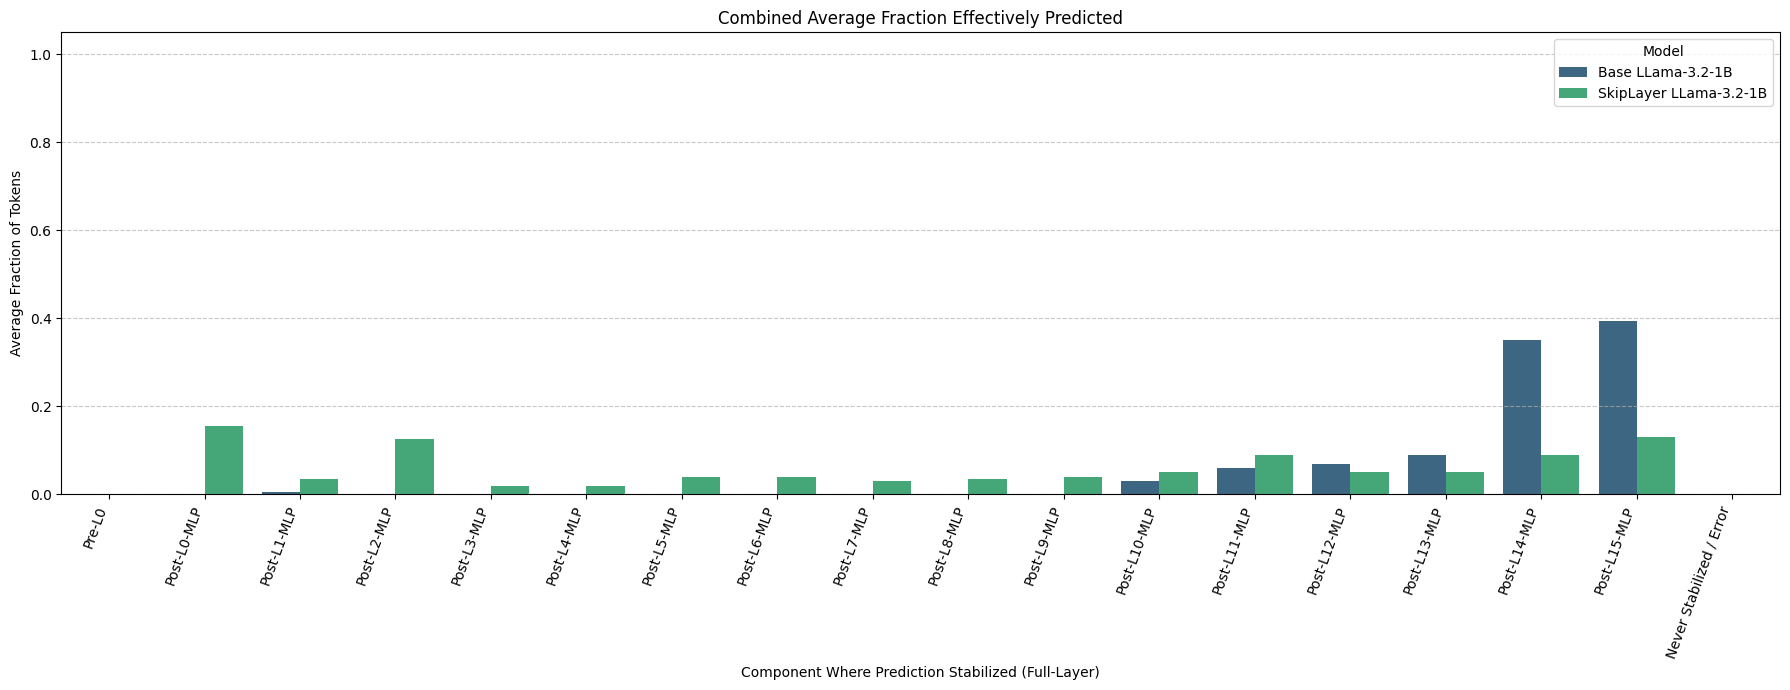


--- Generating Combined Visualization: Combined Cumulative Fraction Effectively Predicted ---


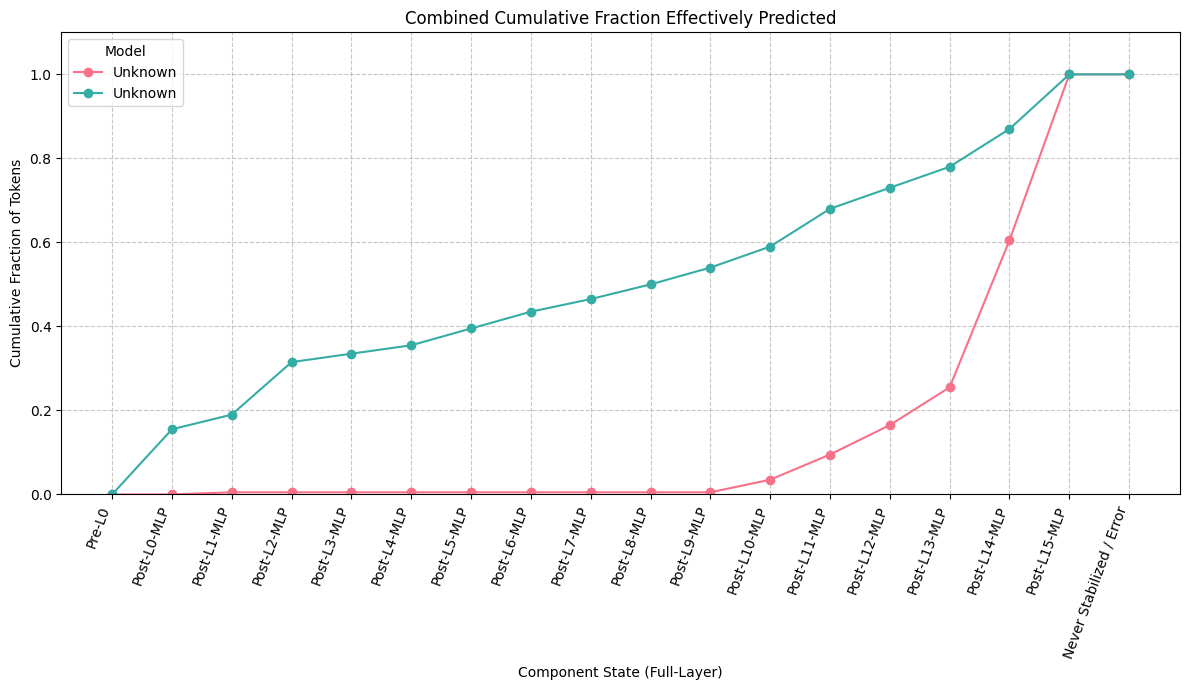


--- Generating Combined Visualization: Combined Average Log Probability Contribution (Sub-Layer) ---


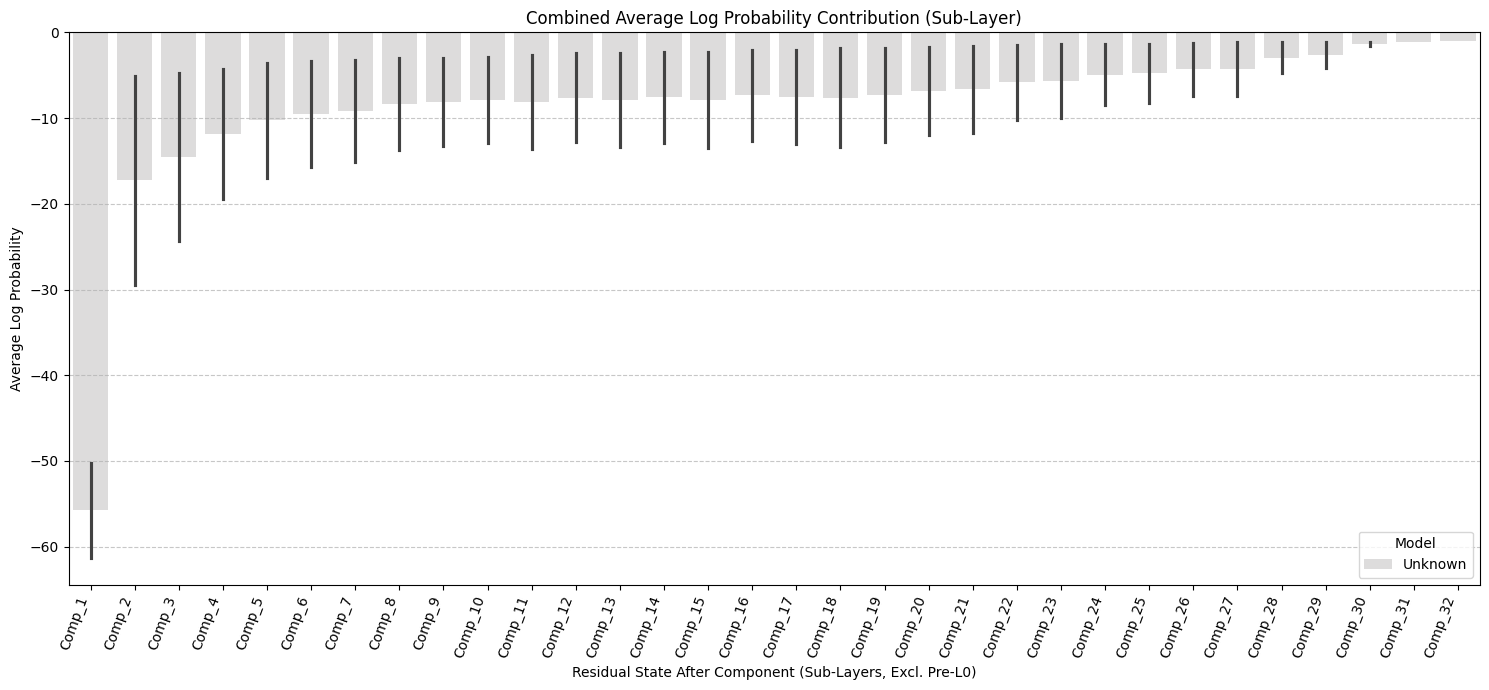


--- Generating Combined Visualization: Combined Average Cumulative Log Probability (Sub-Layer) ---


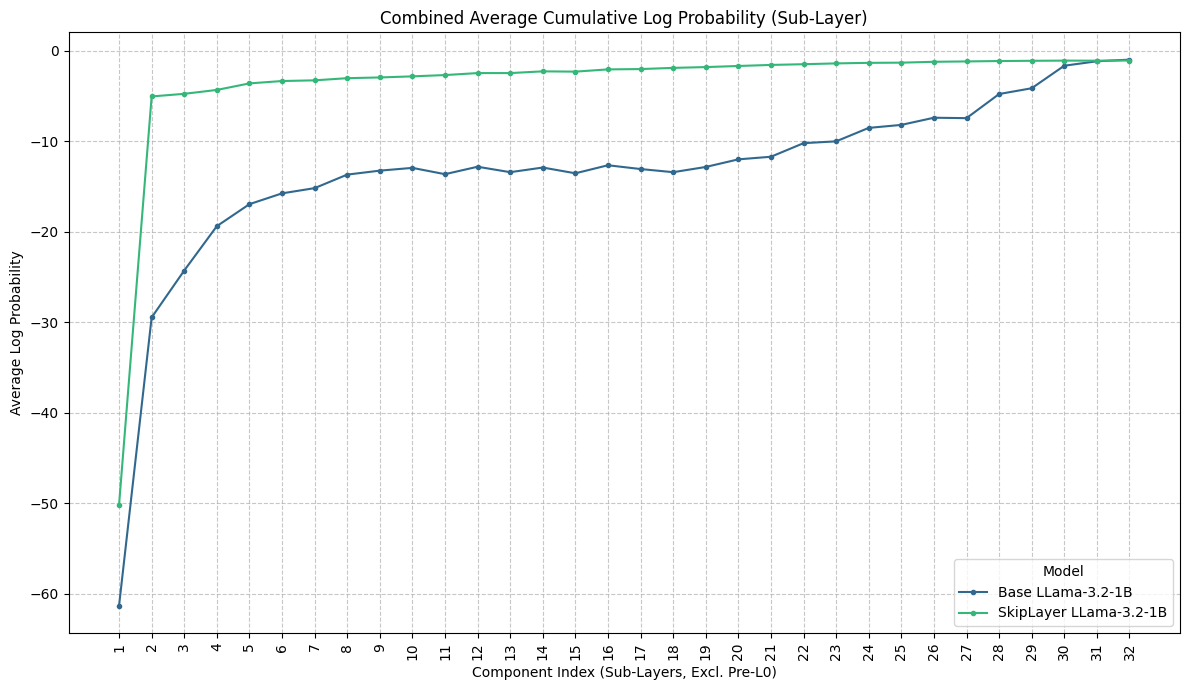


===== Comparative Experiment Run Finished =====


In [33]:
# Assume llamaModelName and modelId are defined elsewhere
configs = [
     {
         'model_id_for_config': llamaModelName,
         'display_name': 'Base LLama-3.2-1B',
         'run_log_prob_analysis' : True,
         'max_new_tokens': 10
     },
     {
         'model_id_for_config': llamaModelName,
         'preload_id_for_weights': modelId,
         'display_name': 'SkipLayer LLama-3.2-1B',
         'run_log_prob_analysis' : True,
         'max_new_tokens': 10
     },
]

comparativeResults = runComparativeExperiment(
     experimentConfigs=configs,
     defaultMaxNewTokens=5,
     defaultRunLogProbAnalysis=True,
     defaultRunEffectivePredAnalysis=True,
     defaultVisualizeIndividualRuns=False,
     defaultUseArcEasyPrompts=True,
     defaultMaxDatasetPrompts=20,
     sharedPrompts=None
)

#CKA Sublayer Analysis

#CKA Sub Layer Analysis Extensions

In [34]:
import torch
from transformer_lens import HookedTransformer
from torch.nn.functional import log_softmax
import pandas as pd
from copy import deepcopy
import os
from transformers import AutoTokenizer
from transformers import AutoModelForCausalLM
from transformers import AutoConfig
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import time
import re # Added import for regex used in sorting
from typing import List, Dict, Tuple, Optional, Any
from collections import defaultdict
from datasets import load_dataset

# Assume TransformerExperiment class is defined elsewhere and already refactored

class RepresentationSimilarityExperiment(TransformerExperiment):
    def __init__(
        self,
        modelId: str,
        hfToken: str = None,
        preloadedModelId: str = None
    ) -> None:
        super().__init__(
            modelId=modelId,
            hfToken=hfToken,
            preloadedModelId=preloadedModelId
        )
        print(
            "RepresentationSimilarityExperiment initialized (for sublayer CKA)."
        )

    @staticmethod
    def centerMatrix(matrixK):
        n = matrixK.size(0)
        if n == 0:
            print("Warning: Trying to center matrix with 0 samples.")
            return matrixK
        identity = torch.eye(n, device=matrixK.device)
        ones = torch.ones((n, n), device=matrixK.device) / n
        h = identity - ones
        return matrixK @ h

    @staticmethod
    def linearCka(
        matrixX: torch.Tensor,
        matrixY: torch.Tensor,
        epsilon = 1e-18
    ) -> tuple:
        if matrixX.shape[0] != matrixY.shape[0]:
            raise ValueError(
                "X and Y must have the same number of samples (rows)."
            )
        if matrixX.ndim != 2 or matrixY.ndim != 2:
            raise ValueError("Inputs must be 2D (samples, features)")
        if matrixX.shape[0] <= 1:
             print(f"Warning: CKA with <= 1 sample ({matrixX.shape[0]}). Returning NaNs.")
             nanT = torch.tensor(float('nan'), device=matrixX.device)
             return (nanT, nanT, nanT, nanT, nanT, nanT)

        matrixX = matrixX.to(torch.float32)
        matrixY = matrixY.to(torch.float32)

        k = matrixX.T @ matrixX
        l = matrixY.T @ matrixY

        kCentered = RepresentationSimilarityExperiment.centerMatrix(k)
        lCentered = RepresentationSimilarityExperiment.centerMatrix(l)

        if kCentered.shape[0]!= kCentered.shape[1] or lCentered.shape[0]!= lCentered.shape[1]:
            print("Warning: Centered matrices not square. Skipping CKA.")
            nanT = torch.tensor(float('nan'), device=matrixX.device)
            return (nanT, k, l, nanT, nanT, nanT)
        if kCentered.shape[1]!= lCentered.shape[0]:
            print(f"Warning: Dim mismatch {kCentered.shape} vs {lCentered.shape}. Skip CKA.")
            nanT = torch.tensor(float('nan'), device=matrixX.device)
            return (nanT, k, l, nanT, nanT, nanT)

        hsic = torch.trace(kCentered @ lCentered)
        hsicXx = torch.trace(kCentered @ kCentered)
        hsicYy = torch.trace(lCentered @ lCentered)

        denominator = torch.sqrt(hsicYy * hsicXx) + epsilon
        if denominator.item() == 0:
             print("Warning: CKA denominator zero.")
             ckaValue = torch.tensor(0.0 if hsic.item() == 0 else float('inf'), device=matrixX.device)
        else:
             ckaValue = hsic / denominator

        ckaValue = torch.clamp(ckaValue, min=-1.0, max=1.0)
        ckaValueNp = ckaValue.detach().cpu().numpy()

        return (ckaValueNp, k, l, hsic, hsicXx, hsicYy)


    def getLayerActivations(
        self,
        inputText: str,
        maxLength: int = None
    ) -> dict[str, torch.Tensor]:
        if not self.model or not self.tokenizer:
            print("Error: Model/tokenizer missing.")
            return {}
        self.model.eval()

        if maxLength is None:
            maxLength = self.model.cfg.n_ctx

        tokens = self.tokenizer.encode(
            inputText,
            return_tensors="pt",
            truncation=True,
            max_length=maxLength
        ).to(self.device)

        activationsForPrompt: dict[str, torch.Tensor] = {}

        embedHookName = "blocks.0.hook_resid_pre"
        layerHookNamesMid = [f"blocks.{idx}.hook_resid_mid" for idx in range(self.model.cfg.n_layers)]
        layerHookNamesPost = [f"blocks.{idx}.hook_resid_post" for idx in range(self.model.cfg.n_layers)]
        embedFallbackHooks = ['hook_embed', 'hook_pos_embed']
        hooksToCapture = layerHookNamesMid + layerHookNamesPost
        useEmbedFallback = False
        if embedHookName in self.model.hook_dict:
            hooksToCapture.insert(0, embedHookName)
        else:
            print(f"Warning: Hook '{embedHookName}' not found. Trying fallback.")
            validFallback = []
            if embedFallbackHooks[0] in self.model.hook_dict:
                 validFallback.append(embedFallbackHooks[0])
            if embedFallbackHooks[1] in self.model.hook_dict:
                 validFallback.append(embedFallbackHooks[1])
            if len(validFallback) == 2:
                 hooksToCapture = validFallback + hooksToCapture
                 useEmbedFallback = True
            else:
                 print(f"Warning: Fallback embedding hooks not found. Embedding layer CKA may fail.")


        with torch.no_grad():
            try:
                _, cache = self.model.run_with_cache(
                    tokens,
                    names_filter=lambda name: name in hooksToCapture
                )

                embedState = None
                if not useEmbedFallback and embedHookName in cache:
                    embedState = cache[embedHookName][0, :, :]
                elif useEmbedFallback and embedFallbackHooks[0] in cache and embedFallbackHooks[1] in cache:
                    embedState = cache[embedFallbackHooks[0]][0,:,:] + cache[embedFallbackHooks[1]][0,:,:]
                if embedState is not None:
                    activationsForPrompt['Embedding'] = embedState.detach().clone()
                else:
                    print(f"Warning: Could not retrieve embedding state for prompt.")

                for layerIdx in range(self.model.cfg.n_layers):
                    hookNameMid = layerHookNamesMid[layerIdx]
                    if hookNameMid in cache:
                        activationsForPrompt[f'L{layerIdx}-Mid'] = cache[hookNameMid][0, :, :].detach().clone()
                    else:
                        print(f"Warning: Hook '{hookNameMid}' not found.")

                    hookNamePost = layerHookNamesPost[layerIdx]
                    if hookNamePost in cache:
                         activationsForPrompt[f'L{layerIdx}-Post'] = cache[hookNamePost][0, :, :].detach().clone()
                    else:
                        print(f"Warning: Hook '{hookNamePost}' not found.")

            except Exception as e:
                print(f"Error during activation retrieval for prompt: {e}")
                return {}

        return activationsForPrompt

    def calculateCkaSimilarityMatrix(
        self,
        activations: dict[str, torch.Tensor]
    ) -> pd.DataFrame:
        if not activations:
            print("Error: Activations dictionary empty.")
            return pd.DataFrame()
        def componentSortKey(name):
            if name == 'Embedding': return (-1, 0)
            match = re.match(r'L(\d+)-(Mid|Post)', name)
            if match: layerNum = int(match.group(1)); step = 1 if match.group(2) == 'Mid' else 2; return (layerNum, step)
            return (float('inf'), 0)
        componentNames = sorted(activations.keys(), key=componentSortKey)
        numComponents = len(componentNames)
        ckaMatrix = pd.DataFrame(np.nan, index=componentNames, columns=componentNames, dtype=float)

        for i in range(numComponents):
            for j in range(i, numComponents):
                name1 = componentNames[i]; name2 = componentNames[j]
                if name1 not in activations or name2 not in activations: continue
                act1 = activations[name1]; act2 = activations[name2]
                similarity = np.nan
                if act1.shape[0] != act2.shape[0]: print(f"Warning: Seq len mismatch {name1}/{name2}. Skip CKA.")
                elif act1.shape[0] < 2: print(f"Warning: Seq len < 2 for {name1}/{name2}. Skip CKA.")
                else:
                     try:
                         similarityTuple = RepresentationSimilarityExperiment.linearCka(matrixX=act1, matrixY=act2)
                         similarity = similarityTuple[0]
                         if isinstance(similarity, np.generic): similarity = similarity.item()
                     except Exception as e: print(f"Error CKA between {name1}/{name2}: {e}")
                ckaMatrix.loc[name1, name2] = similarity
                if i != j: ckaMatrix.loc[name2, name1] = similarity
        np.fill_diagonal(ckaMatrix.values, 1.0)
        return ckaMatrix

    def computeAverageCkaSimilarity(
        self,
        prompts: list[str],
        maxLength: int = 128
    ) -> pd.DataFrame:
        allCkaMatrices: list[pd.DataFrame] = []
        print(f"Computing average SUB-LAYER CKA over {len(prompts)} prompts (maxLength={maxLength})...")

        for i, prompt in enumerate(prompts):
            activations = self.getLayerActivations(
                inputText=prompt,
                maxLength=maxLength
            )

            if not activations:
                print(f"  Skipping prompt {i+1} (activation error).")
                continue

            ckaMatrixPrompt = self.calculateCkaSimilarityMatrix(
                activations=activations
            )

            if not ckaMatrixPrompt.empty:
                if ckaMatrixPrompt.isnull().values.any():
                    print(f"  Warning: CKA matrix for prompt {i+1} has NaNs. Excluding.")
                else:
                    allCkaMatrices.append(ckaMatrixPrompt)
            else:
                print(f"  Skipping prompt {i+1} (CKA matrix error).")

        if not allCkaMatrices:
            print("Error: No valid CKA matrices computed across all prompts.")
            return pd.DataFrame()
        if len(set(m.shape for m in allCkaMatrices)) > 1 or \
           len(set(tuple(m.index) for m in allCkaMatrices)) > 1 or \
           len(set(tuple(m.columns) for m in allCkaMatrices)) > 1:
            print("Error: CKA matrices have inconsistent shapes/indices. Cannot average.")
            return pd.DataFrame()

        averageCkaMatrix = pd.DataFrame(
             np.nanmean(np.array([m.values for m in allCkaMatrices]), axis=0),
             index=allCkaMatrices[0].index,
             columns=allCkaMatrices[0].columns
        )
        print(f"\nAveraged sublayer CKA matrices from {len(allCkaMatrices)} prompts.")
        return averageCkaMatrix

    def visualizeCkaSimilarity(
        self,
        ckaMatrix: pd.DataFrame,
        title: str = None
    ):
        if ckaMatrix.empty:
            print("Cannot visualize empty CKA matrix.")
            return

        plotTitleFull = title if title else f'Sublayer Representational Similarity (CKA) - {self.model.cfg.model_name}'
        figWidthFull = max(20, ckaMatrix.shape[1] * 0.4)
        figHeightFull = max(20, ckaMatrix.shape[0] * 0.4)

        print("Visualizing Full CKA Matrix...")
        plt.figure(figsize=(figWidthFull, figHeightFull))
        sns.heatmap(
            ckaMatrix,
            annot=True,
            fmt=".3f",
            cmap="magma",
            linewidths=.5,
            cbar_kws={'label': 'CKA Similarity'}
        )
        plt.title(plotTitleFull, fontsize=14)
        plt.xlabel("Layer/Sublayer Component", fontsize=12)
        plt.ylabel("Layer/Sublayer Component", fontsize=12)
        plt.xticks(rotation=90)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

        postMlpLabels = [label for label in ckaMatrix.index if label.endswith('-Post')]
        if not postMlpLabels:
             print("No 'Post-MLP' layers found to generate the second plot.")
             return

        ckaMatrixPostMlp = ckaMatrix.loc[postMlpLabels, postMlpLabels]

        plotTitlePost = f'Post-MLP Layer Similarity (CKA) - {self.model.cfg.model_name}'
        figWidthPost = max(10, ckaMatrixPostMlp.shape[1] * 0.5)
        figHeightPost = max(10, ckaMatrixPostMlp.shape[0] * 0.5)

        print("Visualizing Post-MLP Layer CKA Matrix (No Annotations)...")
        plt.figure(figsize=(figWidthPost, figHeightPost))
        sns.heatmap(
            ckaMatrixPostMlp,
            annot=False,
            fmt=".3f",
            cmap="magma",
            linewidths=.5,
            cbar_kws={'label': 'CKA Similarity'}
        )
        plt.title(plotTitlePost, fontsize=14)
        plt.xlabel("Layer (Post-MLP)", fontsize=12)
        plt.ylabel("Layer (Post-MLP)", fontsize=12)
        plt.xticks(rotation=90)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

In [35]:
# import torch
from transformer_lens import HookedTransformer
from torch.nn.functional import log_softmax
import pandas as pd
from copy import deepcopy
import os
from transformers import AutoTokenizer
from transformers import AutoModelForCausalLM
from transformers import AutoConfig
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import time
import re
from typing import List, Dict, Tuple, Optional, Any
from collections import defaultdict
from datasets import load_dataset

# Assume RepresentationSimilarityExperiment class is defined elsewhere and already refactored

def runExperiment(
    modelIdForConfig: str,
    preloadIdForWeights: str = None,
    ckaHookTemplate: str = "blocks.{}.hook_resid_post",
    ckaIncludeEmbedding: bool = True,
    numArcPrompts: int = 50,
    arcSplit: str = 'train',
    arcConfig: str = 'ARC-Challenge'
):
    print(f"--- Starting Experiment Run (ARC Prompt Sublayer CKA) ---")
    timestamp = time.strftime('%Y-%m-%d %H:%M:%S %Z'); print(f"Timestamp: {timestamp}")
    location = "Warsaw, Masovian Voivodeship, Poland"; print(f"Location: {location}")

    hfTokenToUse = None
    print("Attempting HF Login state check (no explicit token passed)...")

    print(f"\n--- Loading {numArcPrompts} prompts from ARC dataset ---")
    print(f"Dataset: ai2_arc, Config: {arcConfig}, Split: {arcSplit}")
    try:
        arcDataset = load_dataset("ai2_arc", arcConfig, split=f"{arcSplit}[:{numArcPrompts}]")
        ckaPrompts = arcDataset['question']
        print(f"Successfully loaded {len(ckaPrompts)} prompts.")
        print("Example prompts:")
        for i, q in enumerate(ckaPrompts[:min(3, len(ckaPrompts))]):
             print(f"  {i+1}: {q[:100]}...")
    except Exception as e:
        print(f"\n--- FAILED TO LOAD ARC DATASET ---")
        print(f"Error: {e}")
        print("Please ensure the 'datasets' library is installed (`pip install datasets`)")
        print("and you have internet access.")
        return

    print(f"\n--- Initializing RepresentationSimilarityExperiment ---")
    print(f"Model ID (for config): {modelIdForConfig}")
    print(f"Preload ID (for weights): {preloadIdForWeights if preloadIdForWeights else 'None'}")
    print(f"HF Token Status for Init: {'None (relying on library login state)'}")
    try:
        experiment = RepresentationSimilarityExperiment(
            modelId=modelIdForConfig,
            hfToken=hfTokenToUse,
            preloadedModelId=preloadIdForWeights
        )
    except Exception as e:
        print(f"\n--- FAILED TO INITIALIZE EXPERIMENT ---"); print(f"Error: {e}")
        return

    print(f"\n--- Computing Average CKA Matrix over {len(ckaPrompts)} ARC prompts ---")
    averageCkaMatrixDf = experiment.computeAverageCkaSimilarity(
        prompts=ckaPrompts,
        maxLength=128
    )

    if not averageCkaMatrixDf.empty:
        print("\nAverage CKA Matrix (Across ARC Prompts):")
        with pd.option_context('display.width', 1000, 'display.max_columns', None, 'display.float_format', '{:,.3f}'.format):
            print(averageCkaMatrixDf)

        print("\nVisualizing Average CKA Matrix...")
        experiment.visualizeCkaSimilarity(
            ckaMatrix=averageCkaMatrixDf,
            title=f'Avg Sublayer CKA ({experiment.modelId}, ARC Prompts)'
        )
    else:
        print("Average CKA Matrix calculation failed or returned empty.")

    print("\n--- Experiment Run Finished ---")

--- Starting Experiment Run (ARC Prompt Sublayer CKA) ---
Timestamp: 2025-04-29 06:58:31 UTC
Location: Warsaw, Masovian Voivodeship, Poland
Attempting HF Login state check (no explicit token passed)...

--- Loading 100 prompts from ARC dataset ---
Dataset: ai2_arc, Config: ARC-Challenge, Split: train


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


train-00000-of-00001.parquet:   0%|          | 0.00/190k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


test-00000-of-00001.parquet:   0%|          | 0.00/204k [00:00<?, ?B/s]

...

validation-00000-of-00001.parquet:   0%|          | 0.00/55.7k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1119 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1172 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/299 [00:00<?, ? examples/s]

Successfully loaded 100 prompts.
Example prompts:
  1: George wants to warm his hands quickly by rubbing them. Which skin surface will produce the most hea...
  2: Which of the following statements best explains why magnets usually stick to a refrigerator door?...
  3: A fold observed in layers of sedimentary rock most likely resulted from the...

--- Initializing RepresentationSimilarityExperiment ---
Model ID (for config): meta-llama/Llama-3.2-1B
Preload ID (for weights): None
HF Token Status for Init: None (relying on library login state)
Using device: cuda
No HF token provided during initialization (relying on HF login state if needed).
No preloadedModelId. Loading 'meta-llama/Llama-3.2-1B' directly.
Loading model 'meta-llama/Llama-3.2-1B' directly with TransformerLens...
Loaded pretrained model meta-llama/Llama-3.2-1B into HookedTransformer
Moving model to device:  cuda
Model 'meta-llama/Llama-3.2-1B' loaded successfully via TransformerLens.
Experiment configured with model: 'Llam

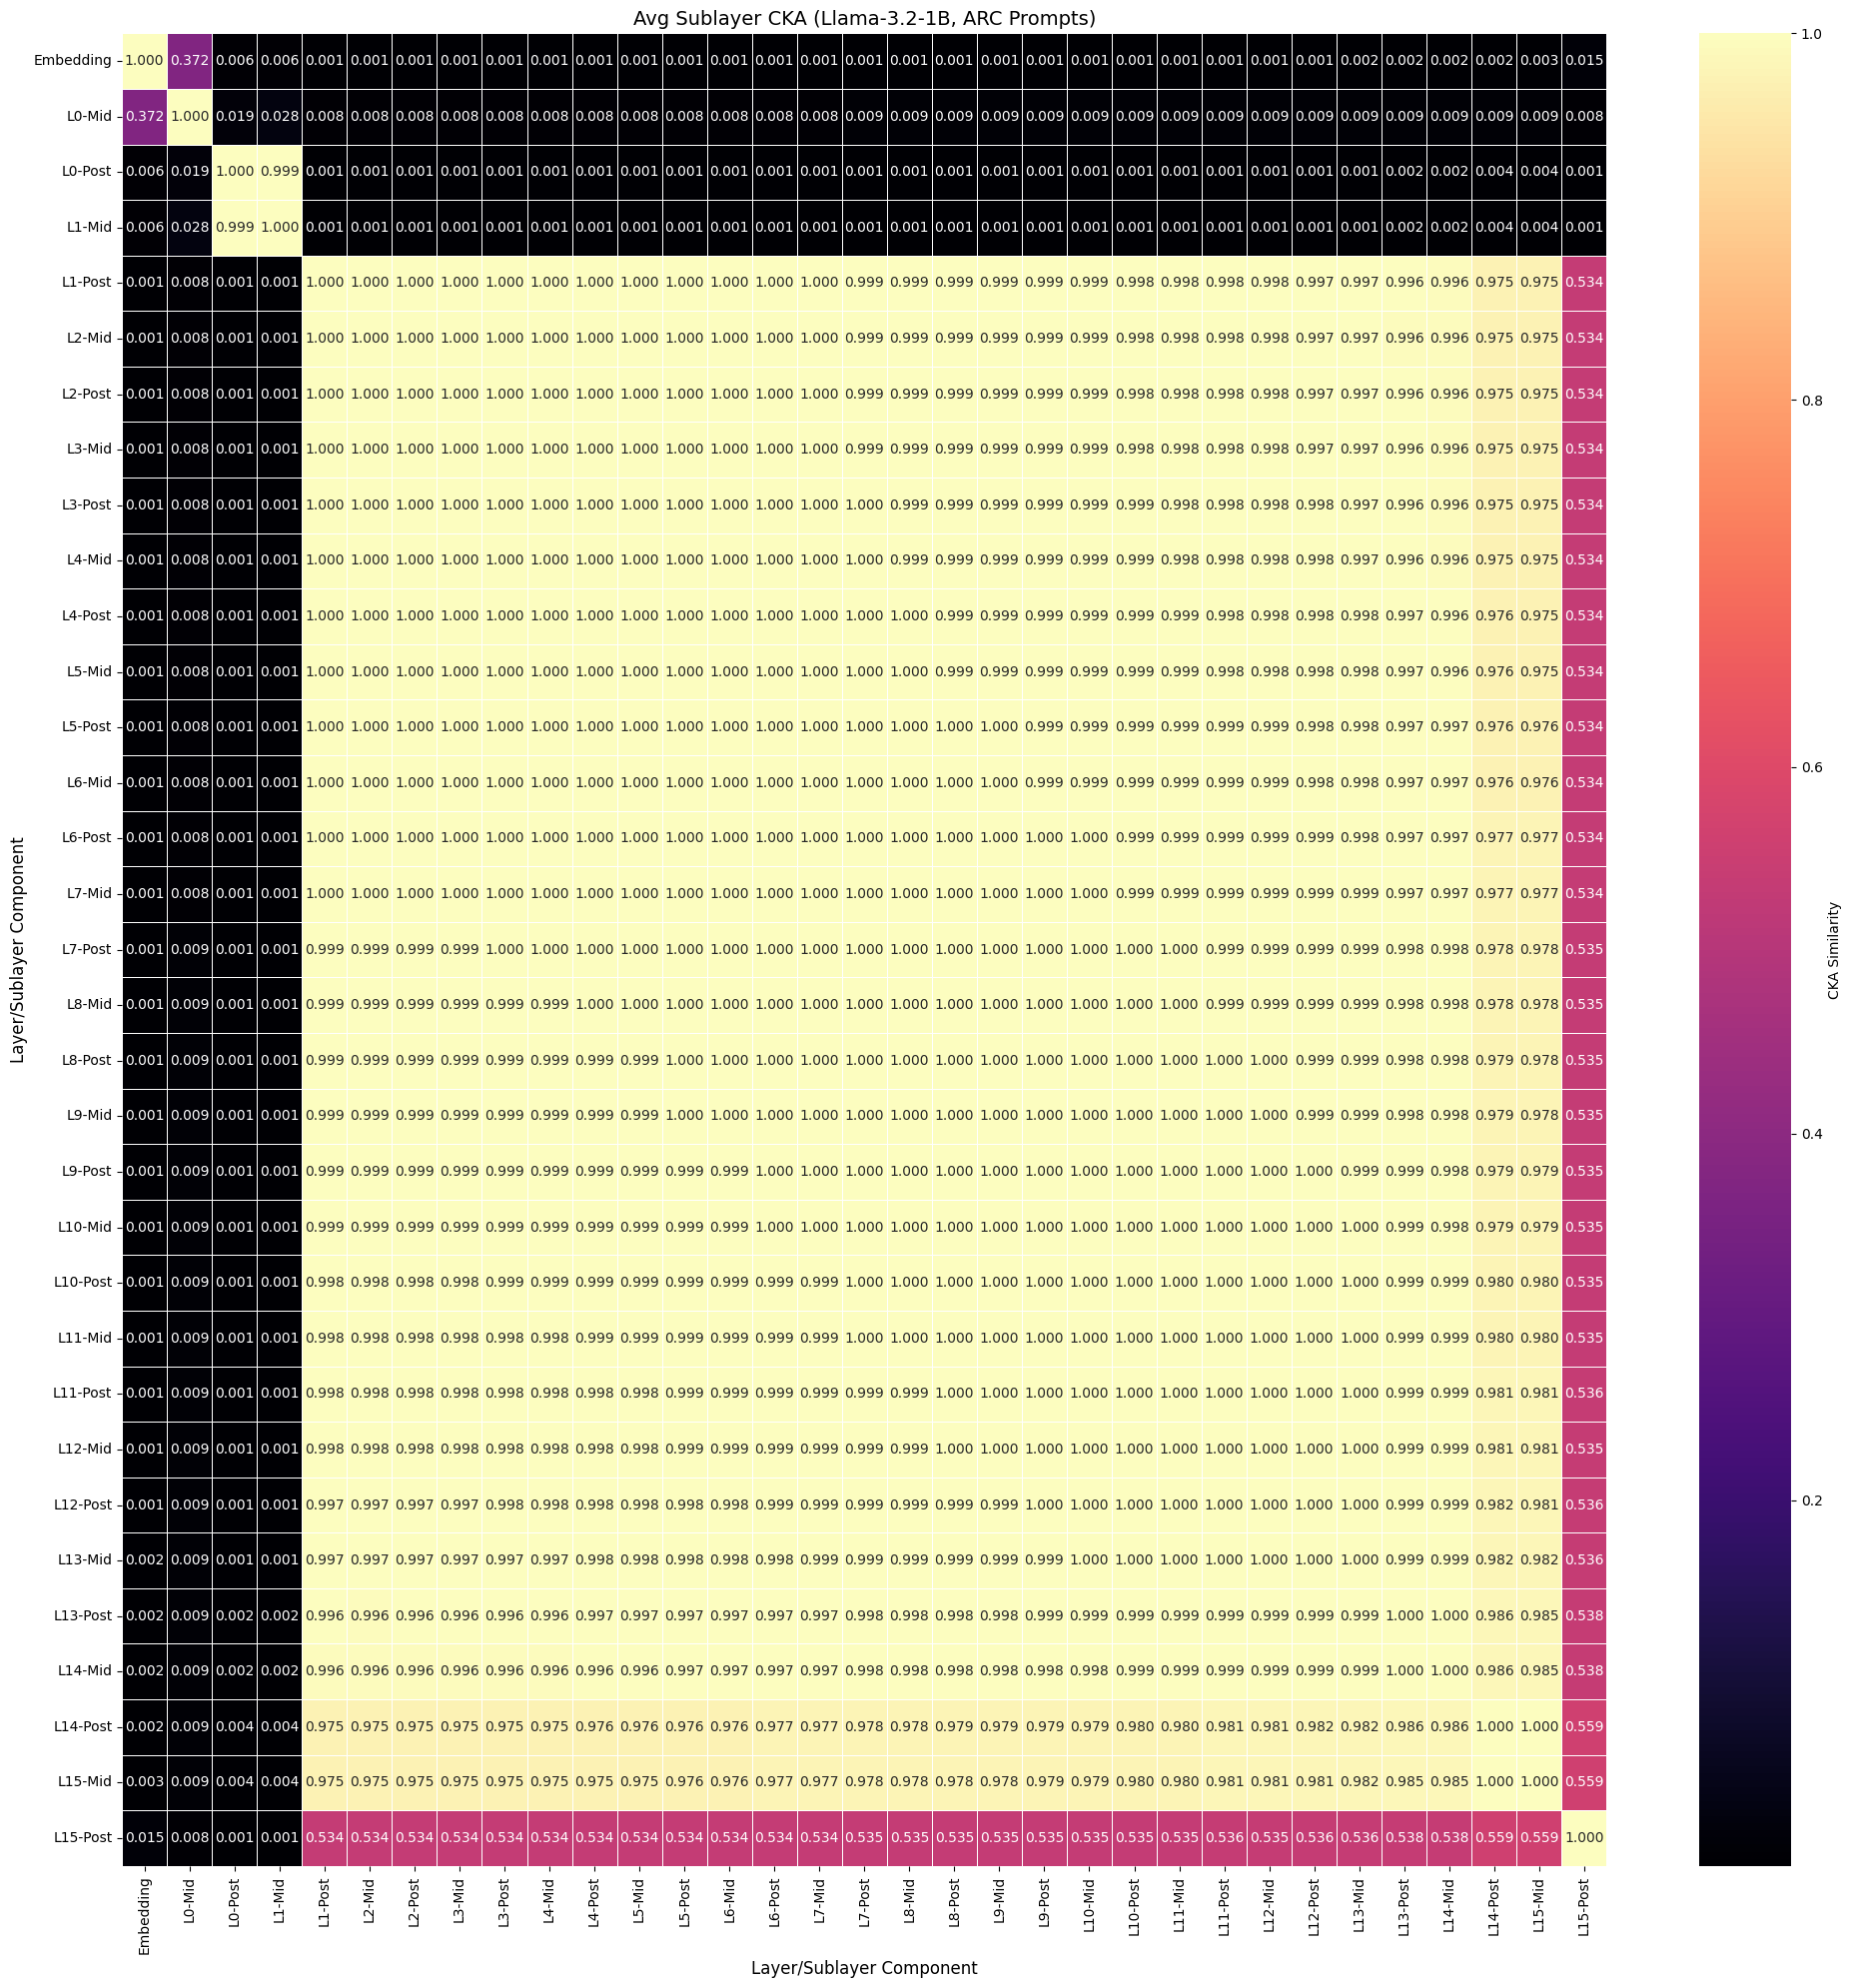

Visualizing Post-MLP Layer CKA Matrix (No Annotations)...


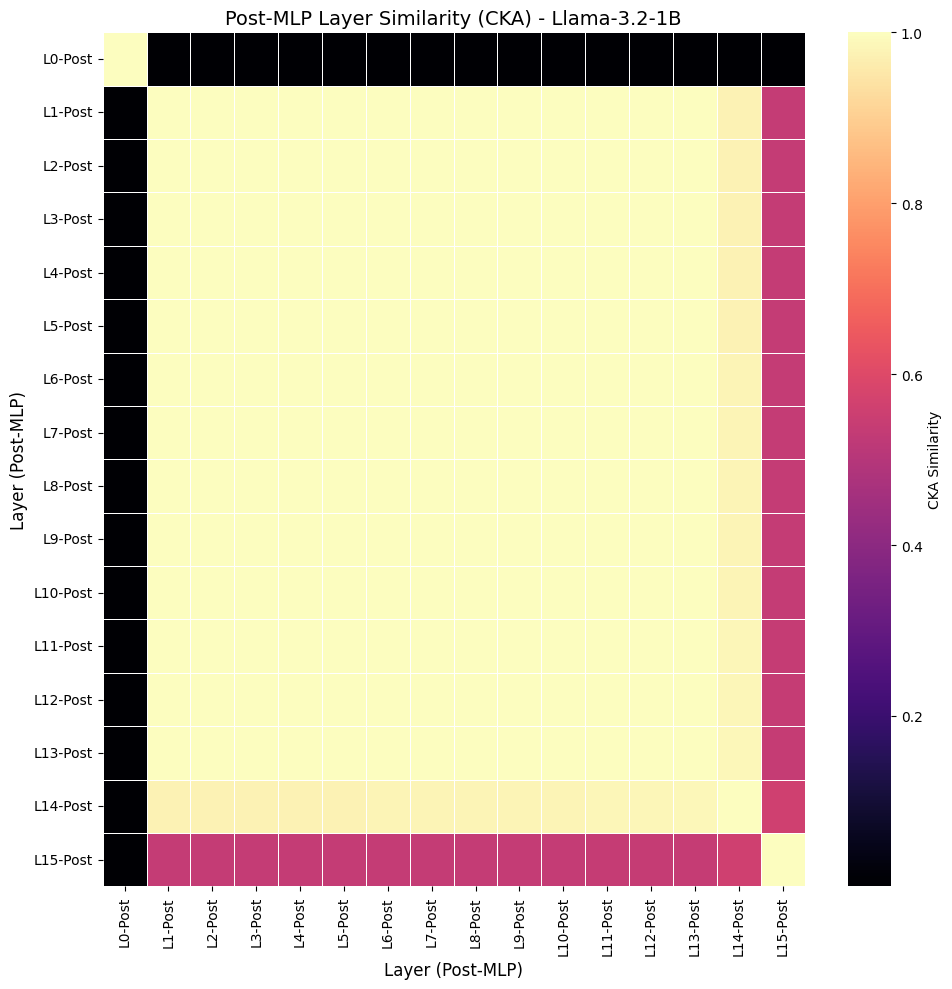


--- Experiment Run Finished ---


In [36]:

if __name__ == "__main__":
    modelToRun = llamaModelName
    preloadNeeded = None

    runExperiment(
        modelIdForConfig=modelToRun,
        preloadIdForWeights=preloadNeeded,
        numArcPrompts=100
    )

--- Starting Experiment Run (ARC Prompt Sublayer CKA) ---
Timestamp: 2025-04-29 07:06:29 UTC
Location: Warsaw, Masovian Voivodeship, Poland
Attempting HF Login state check (no explicit token passed)...

--- Loading 100 prompts from ARC dataset ---
Dataset: ai2_arc, Config: ARC-Challenge, Split: train
Successfully loaded 100 prompts.
Example prompts:
  1: George wants to warm his hands quickly by rubbing them. Which skin surface will produce the most hea...
  2: Which of the following statements best explains why magnets usually stick to a refrigerator door?...
  3: A fold observed in layers of sedimentary rock most likely resulted from the...

--- Initializing RepresentationSimilarityExperiment ---
Model ID (for config): meta-llama/Llama-3.2-1B
Preload ID (for weights): facebook/layerskip-llama3.2-1B
HF Token Status for Init: None (relying on library login state)
Using device: cuda
No HF token provided during initialization (relying on HF login state if needed).
--- Pre-loading HF Mode

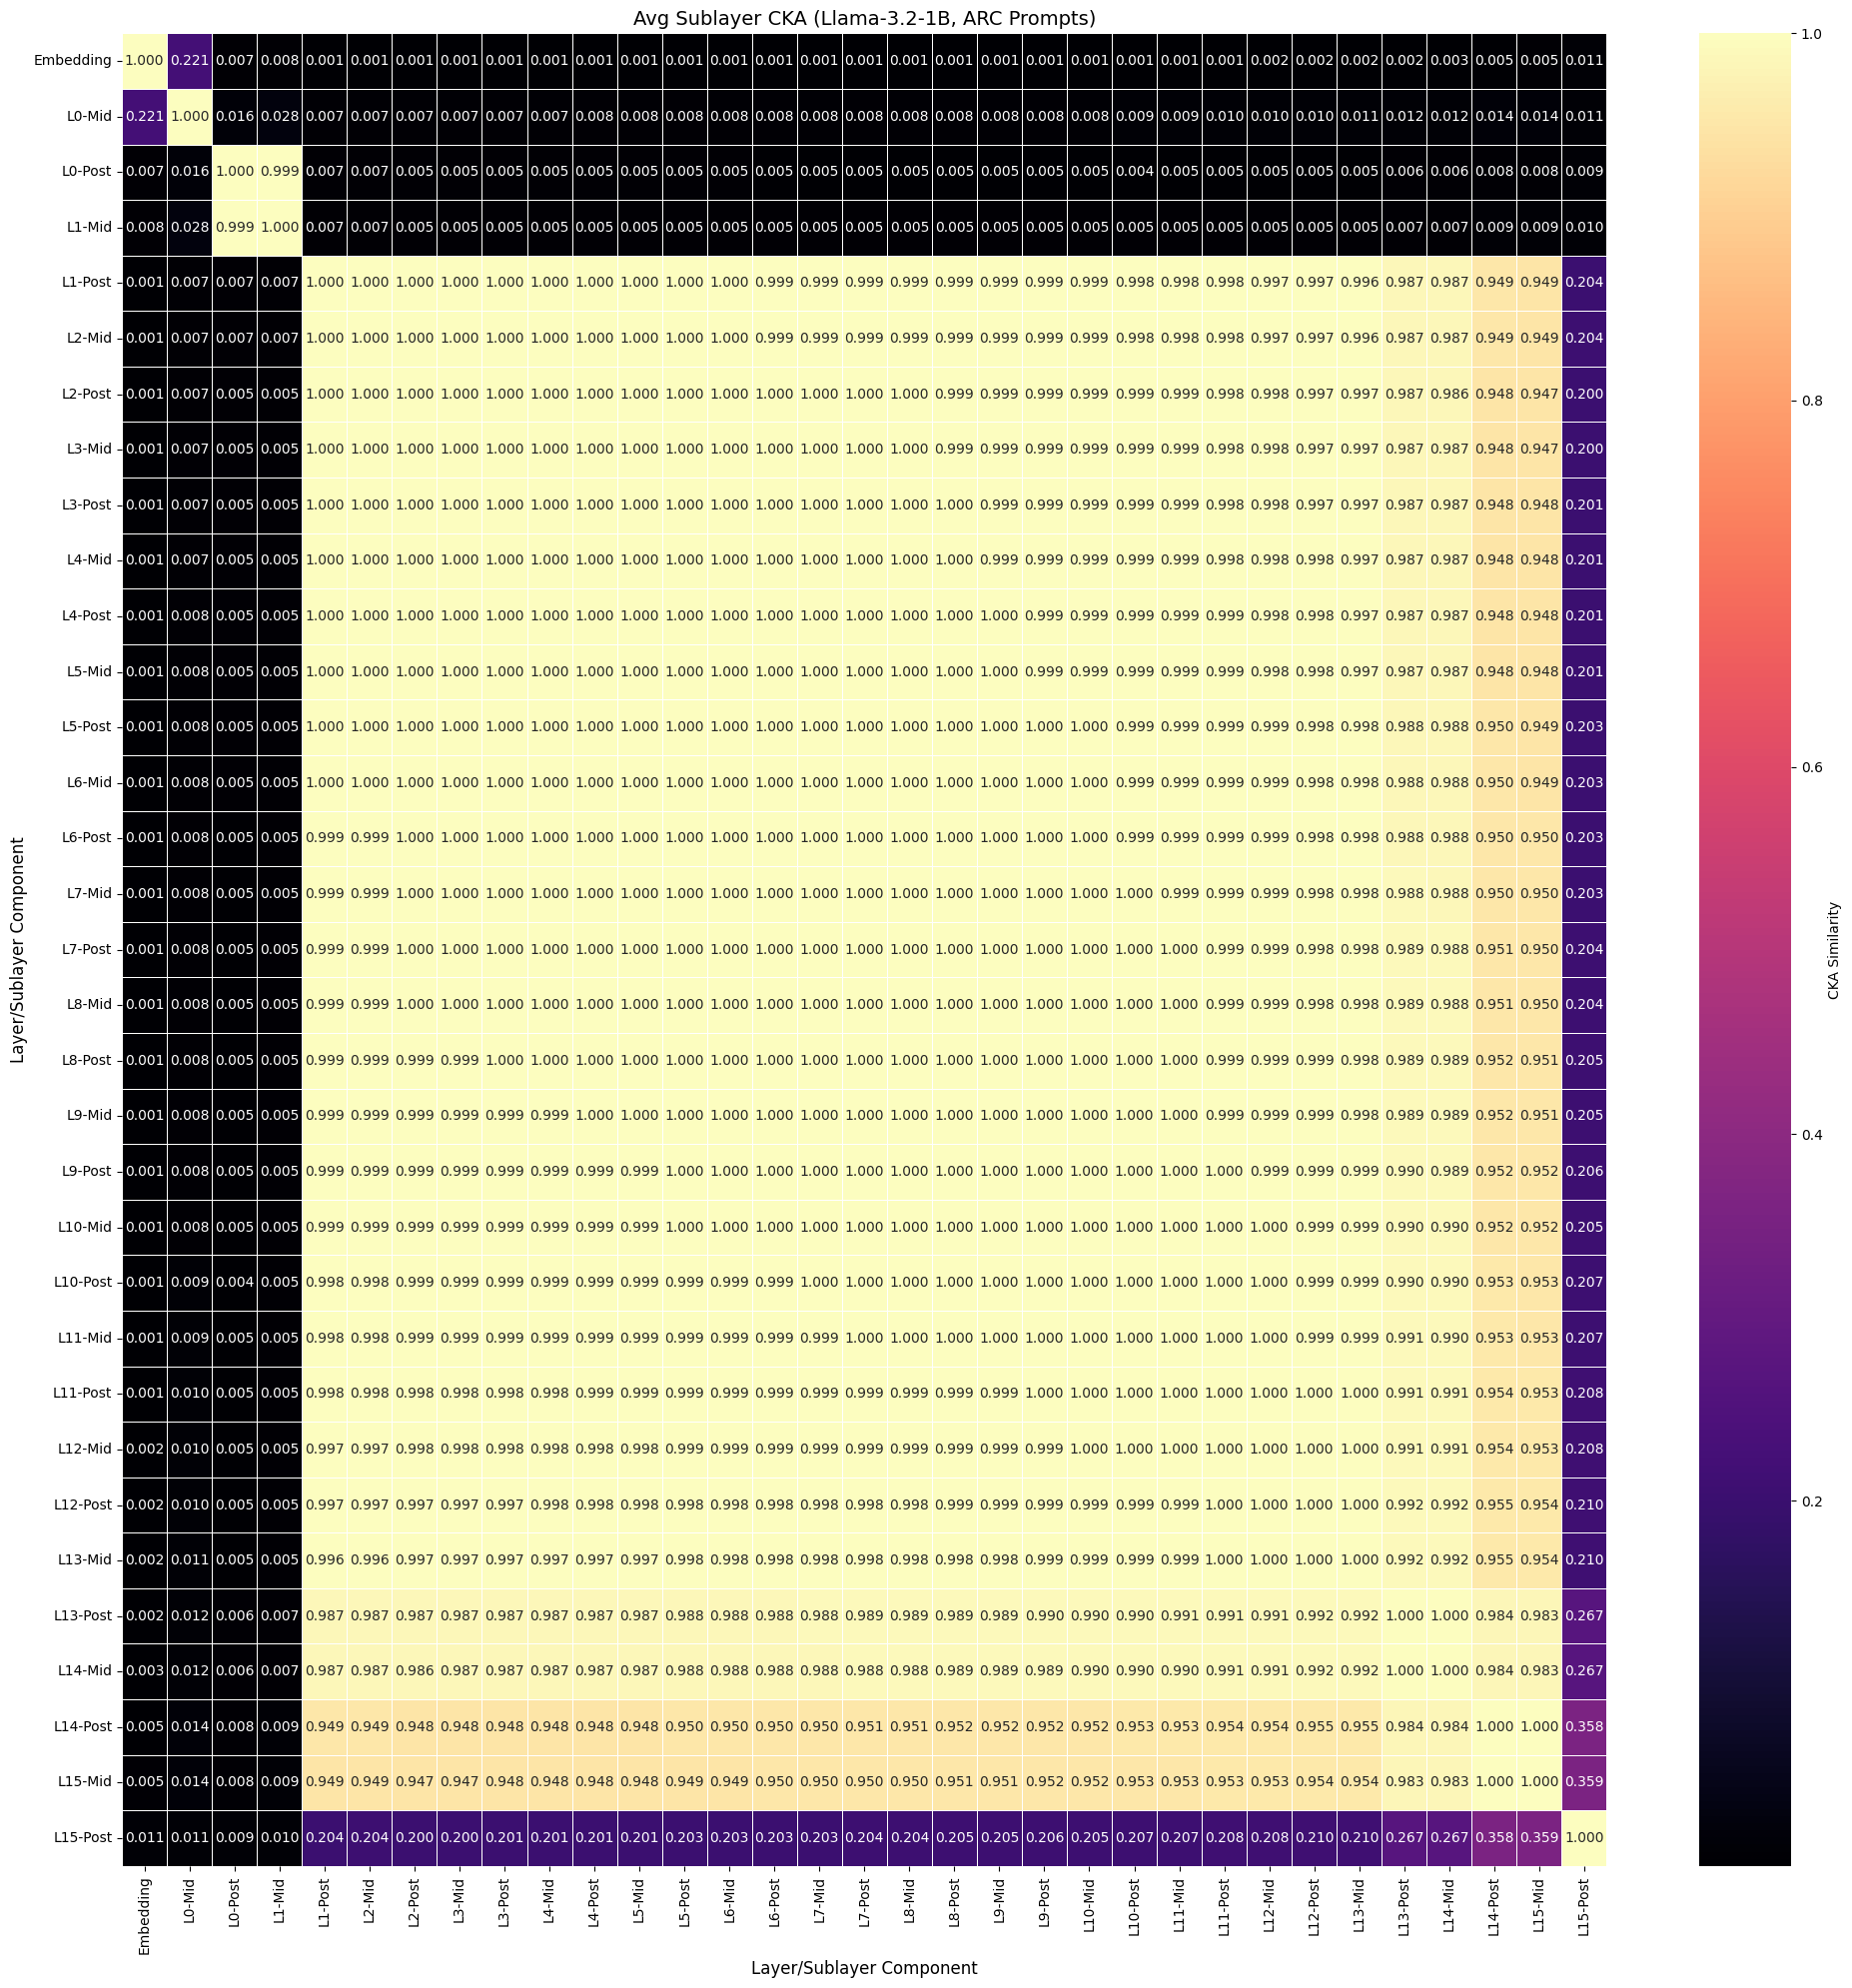

Visualizing Post-MLP Layer CKA Matrix (No Annotations)...


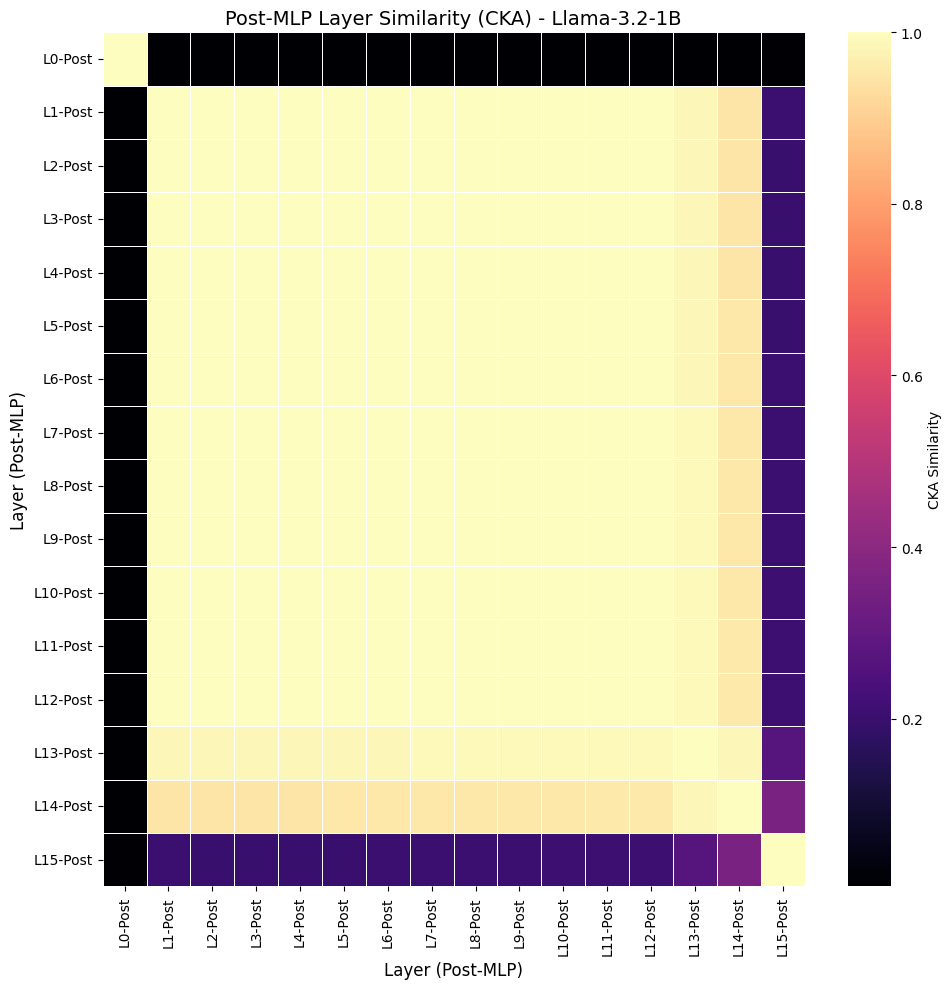


--- Experiment Run Finished ---


In [37]:

if __name__ == "__main__":
    modelToRun = llamaModelName
    preloadNeeded = modelId

    runExperiment(
        modelIdForConfig=modelToRun,
        preloadIdForWeights=preloadNeeded,
        numArcPrompts=100
    )